# Detección de Fraude en Órdenes de E-commerce y Logística


**Dataset:** `ecommerce_logistics.csv` (25,000 órdenes, 26 variables) tomado del sitio: https://www.kaggle.com/datasets/deeplumiere/e-commerce-customer-behavior-and-logistics-dataset

**Fecha:** Agosto de 2026



---

## **Definición del problema de negocio**

### **Contexto del negocio**

La empresa analizada opera una plataforma de comercio electrónico (e-commerce) con logística propia y tercerizada: vende productos en categorías de Electrónica, Ropa, Hogar, Juguetes y Abarrotes, gestiona múltiples métodos de pago (billetera digital, tarjeta de crédito, transferencia bancaria), despacha desde cuatro centros de distribución (Norte, Sur, Este, Oeste) y utiliza transportistas propios y de terceros (aéreo y terrestre) con múltiples modalidades de envío (estándar, exprés, mismo día). En e-commerce, las tasas de fraude reportadas suelen ubicarse entre 1% y 5% del volumen de transacciones, y cada caso de fraude no detectado no solo cuesta el valor de la mercancía sino también comisiones de contracargo, costos logísticos y, en casos frecuentes, penalizaciones de la pasarela de pago. En este dataset, la tasa observada de fraude es del **3.06%** (766 de 25,000 órdenes), coherente con ese rango de industria.

###**Objetivo principal**

Desarrollar un sistema de detección temprana de fraude que permita identificar órdenes con alta probabilidad de ser fraudulentas antes de autorizar su procesamiento y envío. Con ello se busca reducir las pérdidas económicas ocasionadas por transacciones fraudulentas, minimizar los costos operativos asociados a devoluciones y contracargos, y fortalecer la seguridad de las operaciones de comercio electrónico.

### **Procesos del negocio afectados**

El fraude impacta directamente varios procesos estratégicos de una empresa de comercio electrónico:

* **Ventas:** genera pérdidas económicas debido a transacciones fraudulentas, contracargos y cancelaciones de pagos.
* **Logística:** ocasiona costos adicionales por el envío de productos que posteriormente no pueden ser cobrados o son objeto de reclamaciones fraudulentas.
* **Experiencia del cliente:** un sistema de detección poco preciso puede generar falsos positivos, bloqueando compras legítimas y afectando la satisfacción, confianza y fidelización de clientes reales.

### **¿Cómo se toman actualmente las decisiones?**

En el escenario actual, la detección de fraude se realiza principalmente de manera reactiva. En muchos casos, las transacciones sospechosas solo se identifican cuando el pago es desconocido por el cliente o después de que el producto ha sido enviado. Este enfoque incrementa las pérdidas económicas y no aprovecha la información histórica disponible para identificar patrones de comportamiento asociados al fraude.

### **Stakeholders principales**

Los principales actores involucrados son:

* Los propietarios o administradores de las tiendas de comercio electrónico, quienes buscan reducir las pérdidas financieras ocasionadas por fraudes.
* Los equipos de operaciones y logística, responsables del procesamiento y despacho de los pedidos.
* Los clientes legítimos, quienes esperan procesos de compra ágiles y seguros, evitando bloqueos injustificados de sus transacciones.



---

## **Situación actual**

### **Disponibilidad y calidad de los datos**

La información se encuentra almacenada en un archivo en formato CSV que contiene registros estructurados correspondientes a 25.000 órdenes de compra.

Durante la exploración inicial de los datos se identifican diferentes problemas de calidad, entre ellos:

* Registros con posibles inconsistencias.
* Edades fuera de rangos reales.
* Precios extremadamente altos o bajos.
* Distancias de envío poco realistas.
* Pesos y tiempos de entrega con valores negativos.
* Posibles relaciones altamente correlacionadas entre algunas variables.

Estas inconsistencias hacen necesario realizar un proceso de limpieza y preparación de los datos antes del entrenamiento de cualquier modelo de aprendizaje automático.

### **Limitaciones del proceso actual**

El proceso actual de detección de fraude presenta varias limitaciones:

* La identificación del fraude ocurre después de que la transacción ha sido procesada, cuando el impacto económico ya se ha materializado.
* Depende en gran medida de revisiones manuales y del criterio de los analistas.
* Tiene una capacidad limitada para analizar grandes volúmenes de transacciones en tiempo real.
* No aprovecha los patrones complejos que pueden existir entre múltiples variables del comportamiento de compra.

### **Ventajas de la solución propuesta**

La implementación de un modelo de aprendizaje automático permitiría:

* Detectar de forma anticipada transacciones potencialmente fraudulentas.
* Reducir pérdidas económicas por contracargos y devoluciones.
* Automatizar el proceso de evaluación de riesgo.
* Analizar simultáneamente múltiples variables para identificar patrones difíciles de detectar mediante reglas manuales.
* Mejorar continuamente el desempeño del sistema a medida que se incorporen nuevos datos históricos.



---

## **Objetivos del modelo de aprendizaje**

### **Tipo de problema**

El problema corresponde a una **clasificación binaria supervisada**, ya que la variable objetivo (`fraud_flag`) posee dos posibles categorías:

* **Yes:** la orden corresponde a un caso de fraude.
* **No:** la orden es legítima.

### **Objetivo del modelo**

El modelo deberá estimar la probabilidad de que una orden de compra sea fraudulenta antes de su aprobación, permitiendo que las transacciones con mayor riesgo sean revisadas o bloqueadas oportunamente.

### **Criterios de desempeño**

Para que el modelo sea útil desde el punto de vista del negocio, se establece como objetivo alcanzar una precisión (*accuracy*) igual o superior al **75 %**. Sin embargo, debido al costo económico asociado a una transacción fraudulenta no detectada, también será fundamental evaluar métricas como **precisión (Precision), exhaustividad (Recall), F1-Score, matriz de confusión, ROC_AUC	y PR_AUC**, con el fin de encontrar un equilibrio adecuado entre minimizar los fraudes no detectados (falsos negativos) y limitar el número de bloqueos de transacciones legítimas (falsos positivos).

Desde la perspectiva del negocio, resulta preferible revisar manualmente algunas compras legítimas antes que permitir el procesamiento de una transacción fraudulenta que pueda generar pérdidas económicas significativas.

A continuación, es explica de manera breve en que consiste cada métrica de error:

- **Accuracy (exactitud):** proporción de predicciones correctas sobre el total. Simple, pero engañosa con clases desbalanceadas — con 97 % de "No", un modelo que siempre dice "No" acierta el 97 % sin detectar ni un fraude.

- **Precision (precisión):** de todo lo que el modelo marcó como positivo, cuánto era realmente positivo → `VP / (VP + FP)`. Responde: *"cuando digo fraude, ¿acierto?"*. Alta precisión = pocas falsas alarmas.

- **Recall (exhaustividad o sensibilidad):** de todos los positivos reales, cuántos detectó el modelo → `VP / (VP + FN)`. Responde: *"¿cuántos fraudes se me escapan?"*. Alto recall = pocos casos perdidos.

- **F1-Score:** media armónica de precisión y recall → `2·(P·R)/(P+R)`. Un solo número que equilibra ambas metricas; solo es alto si las dos lo son. Útil cuando te importan por igual falsas alarmas y casos perdidos.

- **ROC-AUC:** área bajo la curva de verdaderos positivos vs. falsos positivos, en todos los umbrales. 0,5 = azar, 1,0 = perfecto. Buena para datos balanceados; optimista con desbalance.

- **PR-AUC:** área bajo la curva precisión vs. recall. Se enfoca en la clase minoritaria; su línea base es la proporción de positivos (no 0,5). Más fiable que ROC-AUC cuando la clase positiva es rara.

En una frase: **accuracy** mide el acierto global, **precision** y **recall** miden los dos tipos de error (falsas alarmas vs. casos perdidos), **F1** los combina, y las dos **AUC** evalúan el modelo a través de todos los umbrales — con **PR-AUC** como la métrica preferida en este caso, por el desbalance de `fraud_flag`.

---

## **Flujo de implementación / Pipeline**

Carga Data set → Copia seguridad → EDA → Partición → limpieza → codificación → selección de variables → escalamiento → modelado (escenario sucio vs. limpio) → comparación de resultados.

## **Carga del data set** ##
Importamos las librerias necesarias para la lectura de archivos CSV y buscamos el archivo en las rutas típicas de Google Colab (`/content/`) y del entorno local

In [ ]:
import pandas as pd
import numpy as np

df_raw = pd.read_csv('/content/ecommerce_logistics.csv')
df_raw

,customer_id,customer_age,account_age_months,customer_segment,location_type,order_id,product_category,item_price_usd,quantity,total_order_value_usd,...,shipping_method,weather_conditions_at_dispatch,carrier_type,estimated_delivery_days,actual_delivery_days,delivery_delay_days,delivery_status,customer_review_score,product_returned,fraud_flag
0,CUST-741605EE,47,77,Standard,Urban,ORD-C6515EA8,Clothing,46.92,2,93.83,...,Standard,Clear,Internal_Fleet,3.0,5.4,2.4,Late,4,No,No
1,CUST-2E961085,37,84,Standard,Urban,ORD-6D7DCEBA,Clothing,42.54,4,170.17,...,Standard,Snow,Third_Party_Air,3.0,4.5,1.5,Late,3,No,No
2,CUST-AB491CB0,49,83,Standard,Suburban,ORD-7D996699,Clothing,140.61,1,140.61,...,Standard,Clear,Internal_Fleet,3.0,2.1,-0.9,Cancelled,5,No,No
3,CUST-ED39BF5B,62,79,Standard,Rural,ORD-35A5E670,Toys,29.98,1,29.98,...,Standard,Rain,Third_Party_Ground,3.0,6.5,3.5,Late,4,No,No
4,CUST-E7BE67D0,36,115,Standard,Urban,ORD-8FC091D5,Groceries,10.27,2,20.54,...,Standard,Clear,Third_Party_Air,3.0,2.6,-0.4,On Time,5,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,CUST-644BE3CC,30,31,Standard,Urban,ORD-9084F482,Clothing,10.47,3,31.41,...,Standard,Rain,Internal_Fleet,3.0,6.5,3.5,Late,4,No,No
24996,CUST-3054F304,35,41,Standard,Urban,ORD-DB416E29,Toys,25.11,3,75.33,...,Standard,Clear,Third_Party_Ground,3.0,3.0,0.0,On Time,5,No,No
24997,CUST-3ABF5359,54,45,Standard,Urban,ORD-7BF8EFB8,Home,287.57,2,575.13,...,Standard,Clear,Internal_Fleet,3.0,3.4,0.4,Cancelled,5,No,No
24998,CUST-23B22385,49,36,Standard,Suburban,ORD-30D4D05E,Electronics,1641.55,2,3283.10,...,Standard,Severe Storm,Internal_Fleet,3.0,5.7,2.7,Late,3,No,Yes


## **Copia de seguridad**

Se genera una copia del data set para tener acceso en cualquier momento al dataset crudo

In [ ]:
# Copia del CSV limpio
df_clean = df_raw.copy()
df_clean

,customer_id,customer_age,account_age_months,customer_segment,location_type,order_id,product_category,item_price_usd,quantity,total_order_value_usd,...,shipping_method,weather_conditions_at_dispatch,carrier_type,estimated_delivery_days,actual_delivery_days,delivery_delay_days,delivery_status,customer_review_score,product_returned,fraud_flag
0,CUST-741605EE,47,77,Standard,Urban,ORD-C6515EA8,Clothing,46.92,2,93.83,...,Standard,Clear,Internal_Fleet,3.0,5.4,2.4,Late,4,No,No
1,CUST-2E961085,37,84,Standard,Urban,ORD-6D7DCEBA,Clothing,42.54,4,170.17,...,Standard,Snow,Third_Party_Air,3.0,4.5,1.5,Late,3,No,No
2,CUST-AB491CB0,49,83,Standard,Suburban,ORD-7D996699,Clothing,140.61,1,140.61,...,Standard,Clear,Internal_Fleet,3.0,2.1,-0.9,Cancelled,5,No,No
3,CUST-ED39BF5B,62,79,Standard,Rural,ORD-35A5E670,Toys,29.98,1,29.98,...,Standard,Rain,Third_Party_Ground,3.0,6.5,3.5,Late,4,No,No
4,CUST-E7BE67D0,36,115,Standard,Urban,ORD-8FC091D5,Groceries,10.27,2,20.54,...,Standard,Clear,Third_Party_Air,3.0,2.6,-0.4,On Time,5,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,CUST-644BE3CC,30,31,Standard,Urban,ORD-9084F482,Clothing,10.47,3,31.41,...,Standard,Rain,Internal_Fleet,3.0,6.5,3.5,Late,4,No,No
24996,CUST-3054F304,35,41,Standard,Urban,ORD-DB416E29,Toys,25.11,3,75.33,...,Standard,Clear,Third_Party_Ground,3.0,3.0,0.0,On Time,5,No,No
24997,CUST-3ABF5359,54,45,Standard,Urban,ORD-7BF8EFB8,Home,287.57,2,575.13,...,Standard,Clear,Internal_Fleet,3.0,3.4,0.4,Cancelled,5,No,No
24998,CUST-23B22385,49,36,Standard,Suburban,ORD-30D4D05E,Electronics,1641.55,2,3283.10,...,Standard,Severe Storm,Internal_Fleet,3.0,5.7,2.7,Late,3,No,Yes


## **Inspección inicial - EDA Manual sobre los datos crudos (sin limpieza):**

Analizamos las variables numéricas con medidas de tendencia central, dispersión y posición, calculamos  para cada una cuartiles, IQR, IQR ratio, Outliers, entre otras estadísticas para evaluar su potencial informativo, y las visualizamos con histogramas, boxplots, mapa de calor de correlación y gráficos de barras para las categóricas.

Este EDA se realiza sobre `df_raw` completo solo con fines exploratorios/descriptivos(entender el negocio y los datos).

Se calcula el tamaño del data set:

In [ ]:
df_raw.shape

(25000, 26)

El dataset cuenta con 25000 filas y 26 columnas

Se obtiene la información de cada columna: nombre de la columna, cantidad de datos faltantes, tipo de datos (flotantes, enteros o texto)

In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customer_id                     25000 non-null  object 
 1   customer_age                    25000 non-null  int64  
 2   account_age_months              25000 non-null  int64  
 3   customer_segment                25000 non-null  object 
 4   location_type                   25000 non-null  object 
 5   order_id                        25000 non-null  object 
 6   product_category                25000 non-null  object 
 7   item_price_usd                  25000 non-null  float64
 8   quantity                        25000 non-null  int64  
 9   total_order_value_usd           25000 non-null  float64
 10  discount_applied_percent        25000 non-null  float64
 11  payment_method                  25000 non-null  object 
 12  payment_status                  

In [ ]:
# Verificar valores nulos/datos faltantes

df_raw.isnull().sum()

,0
customer_id,0
customer_age,0
account_age_months,0
customer_segment,0
location_type,0
order_id,0
product_category,0
item_price_usd,0
quantity,0
total_order_value_usd,0


In [ ]:
#Verificar valores duplicados

# 1) Filas completamente duplicadas
print("Filas 100% duplicadas:", df_raw.duplicated().sum())

# 2) order_id duplicados (integridad de la clave de negocio)
print("order_id duplicados:", df_raw.duplicated(subset=['order_id']).sum())
print("order_id únicos:", df_raw['order_id'].nunique(), "de", len(df_raw), "filas")

# 3) Mostrar las filas implicadas para probar que son órdenes DISTINTAS
dups = df_raw[df_raw.duplicated(subset=['order_id'], keep=False)]
print(dups[['customer_id', 'order_id', 'product_category',
            'item_price_usd', 'total_order_value_usd']])

Filas 100% duplicadas: 0
order_id duplicados: 1
order_id únicos: 24999 de 25000 filas
        customer_id      order_id product_category  item_price_usd  \
7177  CUST-66B78B15  ORD-A85B650E         Clothing           27.75   
8186  CUST-7D04B0D0  ORD-A85B650E      Electronics         1906.84   

      total_order_value_usd  
7177                 110.98  
8186                3813.67  


In [ ]:
#Verificación de errores tipograficos en columnas categóricas

columnas_categoricas = ['customer_segment', 'location_type', 'product_category',
                         'payment_method', 'payment_status', 'warehouse_location',
                         'shipping_method', 'weather_conditions_at_dispatch',
                         'carrier_type', 'delivery_status', 'product_returned']

for col in columnas_categoricas:
    print(f"--- {col} ---")
    print(df_raw[col].unique())
    print()

--- customer_segment ---
['Standard' 'Premium' 'VIP']

--- location_type ---
['Urban' 'Suburban' 'Rural']

--- product_category ---
['Clothing' 'Toys' 'Groceries' 'Home' 'Electronics']

--- payment_method ---
['Digital Wallet' 'Credit Card' 'Bank Transfer']

--- payment_status ---
['Success' 'Failed']

--- warehouse_location ---
['North' 'South' 'West' 'East']

--- shipping_method ---
['Standard' 'Same-Day' 'Express']

--- weather_conditions_at_dispatch ---
['Clear' 'Snow' 'Rain' 'Severe Storm']

--- carrier_type ---
['Internal_Fleet' 'Third_Party_Air' 'Third_Party_Ground']

--- delivery_status ---
['Late' 'Cancelled' 'On Time']

--- product_returned ---
['No' 'Yes']



In [ ]:
# Verificación de coincidencia entre 'total_order_value_usd' contra el valor calculado
# en función de 'item_price_usd', 'quantity' y 'discount_applied_percent':

# Fórmula con descuento (la que se asumiría "lógica")
total_con_desc = df_raw['item_price_usd'] * df_raw['quantity'] * (1 - df_raw['discount_applied_percent']/100)

# Diferencia frente al total registrado (tolerancia de 5 centavos por redondeo)
no_coincide = (df_raw['total_order_value_usd'] - total_con_desc).abs() > 0.05

print(f"Filas donde total = precio*cant*(1-desc): {no_coincide.sum()} "
      f"({no_coincide.mean():.2%})")

Filas donde total = precio*cant*(1-desc): 12889 (51.56%)


In [ ]:
# compara también contra precio × cantidad sin descuento:

total_sin_desc = df_raw['item_price_usd'] * df_raw['quantity']
coincide_sin_desc = (df_raw['total_order_value_usd'] - total_sin_desc).abs() <= 0.05

print(f"Coincide con precio*cantidad SIN descuento: {coincide_sin_desc.mean():.2%}")

Coincide con precio*cantidad SIN descuento: 99.72%


In [ ]:
# Verificación visual del valor total con y sin descuento aplicado

muestra = df_raw[df_raw['discount_applied_percent'] > 0].head(8).copy()
muestra['sin_desc'] = muestra['item_price_usd'] * muestra['quantity']
muestra['con_desc'] = muestra['sin_desc'] * (1 - muestra['discount_applied_percent']/100)
print(muestra[['item_price_usd', 'quantity', 'discount_applied_percent',
               'total_order_value_usd', 'sin_desc', 'con_desc']])

    item_price_usd  quantity  discount_applied_percent  total_order_value_usd  \
1            42.54         4                      10.0                 170.17   
4            10.27         2                       5.0                  20.54   
6            32.89         4                       5.0                 131.57   
7           237.84         2                      10.2                 475.69   
10           36.32         3                      21.7                 108.95   
12           21.16         8                      10.3                 169.25   
13           37.78         7                       7.9                 264.46   
15          375.38         3                       5.0                1126.15   

    sin_desc    con_desc  
1     170.16   153.14400  
4      20.54    19.51300  
6     131.56   124.98200  
7     475.68   427.16064  
10    108.96    85.31568  
12    169.28   151.84416  
13    264.46   243.56766  
15   1126.14  1069.83300  


Ninguna de las columnas hay valores nulos y los tipos de datos de las columnas son coherentes con la información que cada una almacena.

No hay Filas 100% duplicadas, sin embargo, se identifica un `order_id` duplicado (24.999 únicos de 25.000 filas): ORD-A85B650E pero con los demás valores diferentes (clientes, categorías y montos) — es decir, dos órdenes reales compartiendo un identificador que debería ser único.

No se identifican errores tipográficos

La columna `total_order_value_usd` se calculó como precio × cantidad sin aplicar el descuento. Por eso la fórmula con descuento falla en la mitad de las filas (12.900 filas, ~51,6 %), justo en las que tienen `discount_applied_percent` > 0



Para cada columna del dataset, se calcula la media, la desviación estándar, los cuartiles (25%, 50%, 75%,) y los valores mínimo y máximo. También se calcula la mediana, moda, varianza, desviación estándar, Percentil 95, IQR, IQR ratio, limites superior e inferior para detección de outliers y número de outliers.



In [ ]:
df_raw.describe()

,customer_age,account_age_months,item_price_usd,quantity,total_order_value_usd,discount_applied_percent,shipping_distance_km,package_weight_kg,estimated_delivery_days,actual_delivery_days,delivery_delay_days,customer_review_score
count,25000.000000,25000.000000,2.500000e+04,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,41.052000,60.456440,1.125968e+04,2.797400,535.190529,5.472912,2641.687516,8.179044,2.899760,4.050892,1.204468,4.368320
std,29.348953,34.918049,2.725865e+05,1.955532,734.028149,6.843618,36213.338529,9.257966,0.664627,2.118015,1.823224,0.775554
min,18.000000,1.000000,5.000000e+00,1.000000,5.300000,0.000000,5.000000,-9.940000,1.000000,-15.000000,-2.900000,1.000000
25%,29.000000,30.000000,4.168000e+01,1.000000,109.270000,0.000000,289.000000,1.790000,3.000000,2.700000,-0.100000,4.000000
50%,40.000000,60.000000,9.323500e+01,2.000000,253.885000,5.000000,506.800000,4.000000,3.000000,3.800000,0.900000,5.000000
75%,50.000000,91.000000,3.240125e+02,4.000000,586.935000,10.000000,812.600000,12.092500,3.000000,5.200000,2.200000,5.000000
max,982.000000,120.000000,9.915890e+06,10.000000,3998.980000,30.000000,971234.900000,40.000000,9.000000,13.000000,10.000000,5.000000


In [ ]:
# Se importan las librerias necesarias y se diferencian las columnas numéricas de las columnas categóricas
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

cols_num = ['customer_age', 'account_age_months', 'item_price_usd', 'quantity',
            'total_order_value_usd', 'discount_applied_percent', 'shipping_distance_km',
            'package_weight_kg', 'estimated_delivery_days', 'actual_delivery_days',
            'delivery_delay_days', 'customer_review_score']

cols_cat = ['customer_segment', 'location_type', 'product_category', 'payment_method',
            'payment_status', 'warehouse_location', 'shipping_method',
            'weather_conditions_at_dispatch', 'carrier_type', 'delivery_status',
            'product_returned', 'fraud_flag']

In [ ]:
# Resumen estadístico, IQR, IQR Ratio, Outliers
def resumen_estadistico(df_raw, cols):
    '''Calcula medidas de tendencia central, dispersión y posición para columnas numéricas.'''
    filas = []
    for c in cols:
        s = df_raw[c].dropna()
        moda = s.mode()

        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1

        lim_inf_outlier_val = max(q1 - 1.5 * iqr, 0)
        lim_sup_outlier_val = q3 + 1.5 * iqr

        # Handle potential division by zero for IQR_ratio
        range_val = s.max() - s.min()
        iqr_ratio_val = iqr / range_val if range_val != 0 else np.nan

        filas.append({
            "variable": c,
            "media": s.mean(),
            "mediana": s.median(),
            "moda": moda.iloc[0] if len(moda) else np.nan,
            "desv_estandar": s.std(),
            "varianza": s.var(),
            "p25": q1,
            "p50": s.quantile(0.50),
            "p75": q3,
            "p95": s.quantile(0.95),
            "IQR": iqr,
            "IQR_ratio": iqr_ratio_val,
            "lim inf Outlier": lim_inf_outlier_val,
            "lim sup Outlier": lim_sup_outlier_val,
            "n_out": ((s < lim_inf_outlier_val) | (s > lim_sup_outlier_val)).sum(),
            "min": s.min(),
            "max": s.max(),
        })
    return pd.DataFrame(filas).set_index("variable").round(3)

tabla_resumen = resumen_estadistico(df_raw, cols_num)
tabla_resumen

,media,mediana,moda,desv_estandar,varianza,p25,p50,p75,p95,IQR,IQR_ratio,lim inf Outlier,lim sup Outlier,n_out,min,max
variable,,,,,,,,,,,,,,,,
customer_age,41.052,40.000,18.00,29.349,8.613610e+02,29.00,40.000,50.000,64.000,21.000,0.022,0.0,81.500,114,18.00,982.00
account_age_months,60.456,60.000,2.00,34.918,1.219270e+03,30.00,60.000,91.000,115.000,61.000,0.513,0.0,182.500,0,1.00,120.00
item_price_usd,11259.681,93.235,10.83,272586.474,7.430339e+10,41.68,93.235,324.012,1566.092,282.332,0.000,0.0,747.511,3338,5.00,9915889.74
quantity,2.797,2.000,2.00,1.956,3.824000e+00,1.00,2.000,4.000,7.000,3.000,0.333,0.0,8.500,765,1.00,10.00
total_order_value_usd,535.191,253.885,123.77,734.028,5.387973e+05,109.27,253.885,586.935,2102.589,477.665,0.120,0.0,1303.432,2979,5.30,3998.98
discount_applied_percent,5.473,5.000,0.00,6.844,4.683500e+01,0.00,5.000,10.000,20.200,10.000,0.333,0.0,25.000,615,0.00,30.00
shipping_distance_km,2641.688,506.800,364.80,36213.339,1.311406e+09,289.00,506.800,812.600,1458.425,523.600,0.001,0.0,1598.000,897,5.00,971234.90
package_weight_kg,8.179,4.000,1.23,9.258,8.571000e+01,1.79,4.000,12.092,30.560,10.302,0.206,0.0,27.546,1825,-9.94,40.00
estimated_delivery_days,2.900,3.000,3.00,0.665,4.420000e-01,3.00,3.000,3.000,4.000,0.000,0.000,3.0,3.000,6811,1.00,9.00


**Interpretación de negocio (medidas de tendencia central y dispersión):** la media de `customer_age` (41 años) es engañosa por la presencia de edades imposibles (hasta 982); la mediana (40) es más confiable. Lo mismo ocurre con `item_price_usd`: la media (USD 11,260) está muy por encima de la mediana (USD 93), lo que delata una **fuerte asimetría positiva** causada por outliers extremos, no por que los productos sean realmente caros en promedio. `shipping_distance_km` muestra el mismo patrón (media 2,642 km vs. mediana 507 km). Estas diferencias entre media y mediana son, en sí mismas, evidencia estadística de outliers antes incluso de graficar nada.

Por la naturaleza de las variables, los límites inferiores para detectar outliers no pueden ser menores de cero, cuando esto ocurre se deja como limite inferior el cero.

**Análisis del IQR ratio por variable:**

- **`item_price_usd`, `shipping_distance_km`, `package_weight_kg`, `delivery_delay_days`, `actual_delivery_days`:** IQR ratio relativamente alto → hay una proporción no trivial de valores fuera del rango, por lo tanto la variable necesita tratamiento (limitación por percentil, transformación logarítmica o escalamiento robusto) antes de entrar al modelo, porque en su forma cruda estos outliers extremos (p. ej. USD 9.9 millones) dominarían cualquier modelo sensible a escala (como la Regresión Logística).
- **`customer_age`, `account_age_months`, `quantity`, `discount_applied_percent`, `estimated_delivery_days`, `customer_review_score`:** IQR ratio bajo → distribuciones razonablemente concentradas, con pocos valores atípicos. Son variables que, tras corregir los pocos valores claramente erróneos, aportan señal directa y estable al modelo sin requerir transformaciones agresivas.
- Un IQR ratio cercano a 0 en una variable con varianza también cercana a 0 sería la única señal de alerta de "columna sin información" (varianza casi nula); no es el caso de ninguna variable numérica de este dataset.

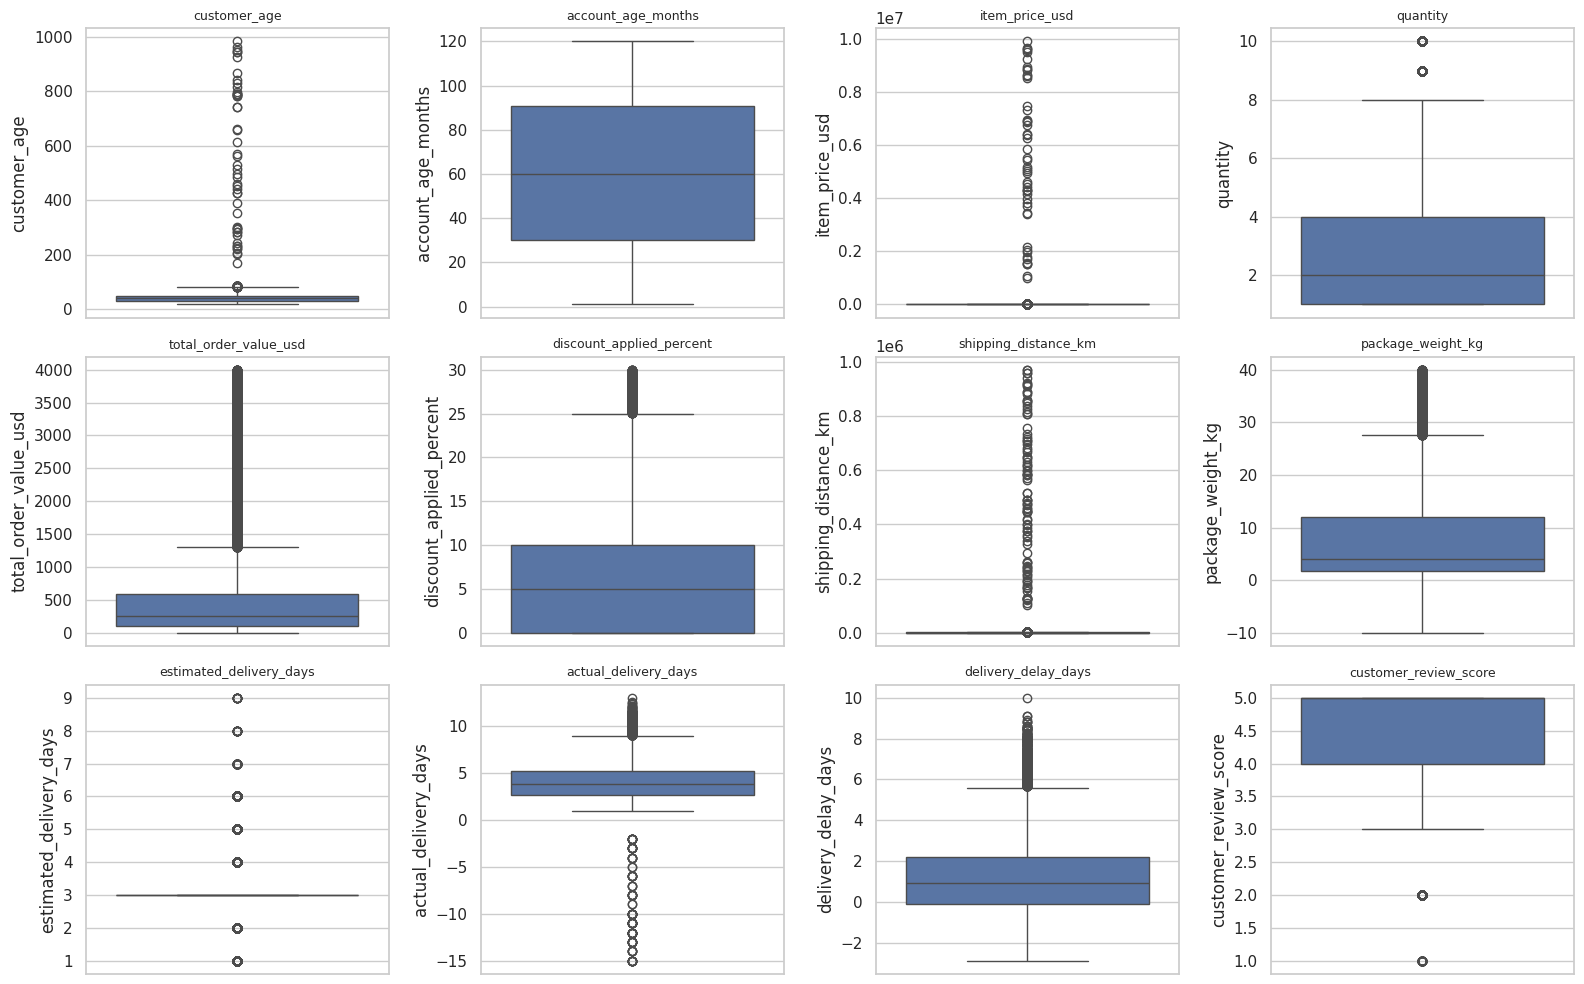

In [ ]:
# Se grafica Boxplot para las columnas numéricas
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, col in zip(axes.flat, cols_num):
    sns.boxplot(y=df_raw[col], ax=ax)
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.show()

 Se grafica histogramas para las variables numéricas que no evidencian "aplastamiento" del Boxplot, es decir que no presentan valores extremos demasiado grandes. Para esas variables es necesario realizar una limpieza antes de graficar el histograma

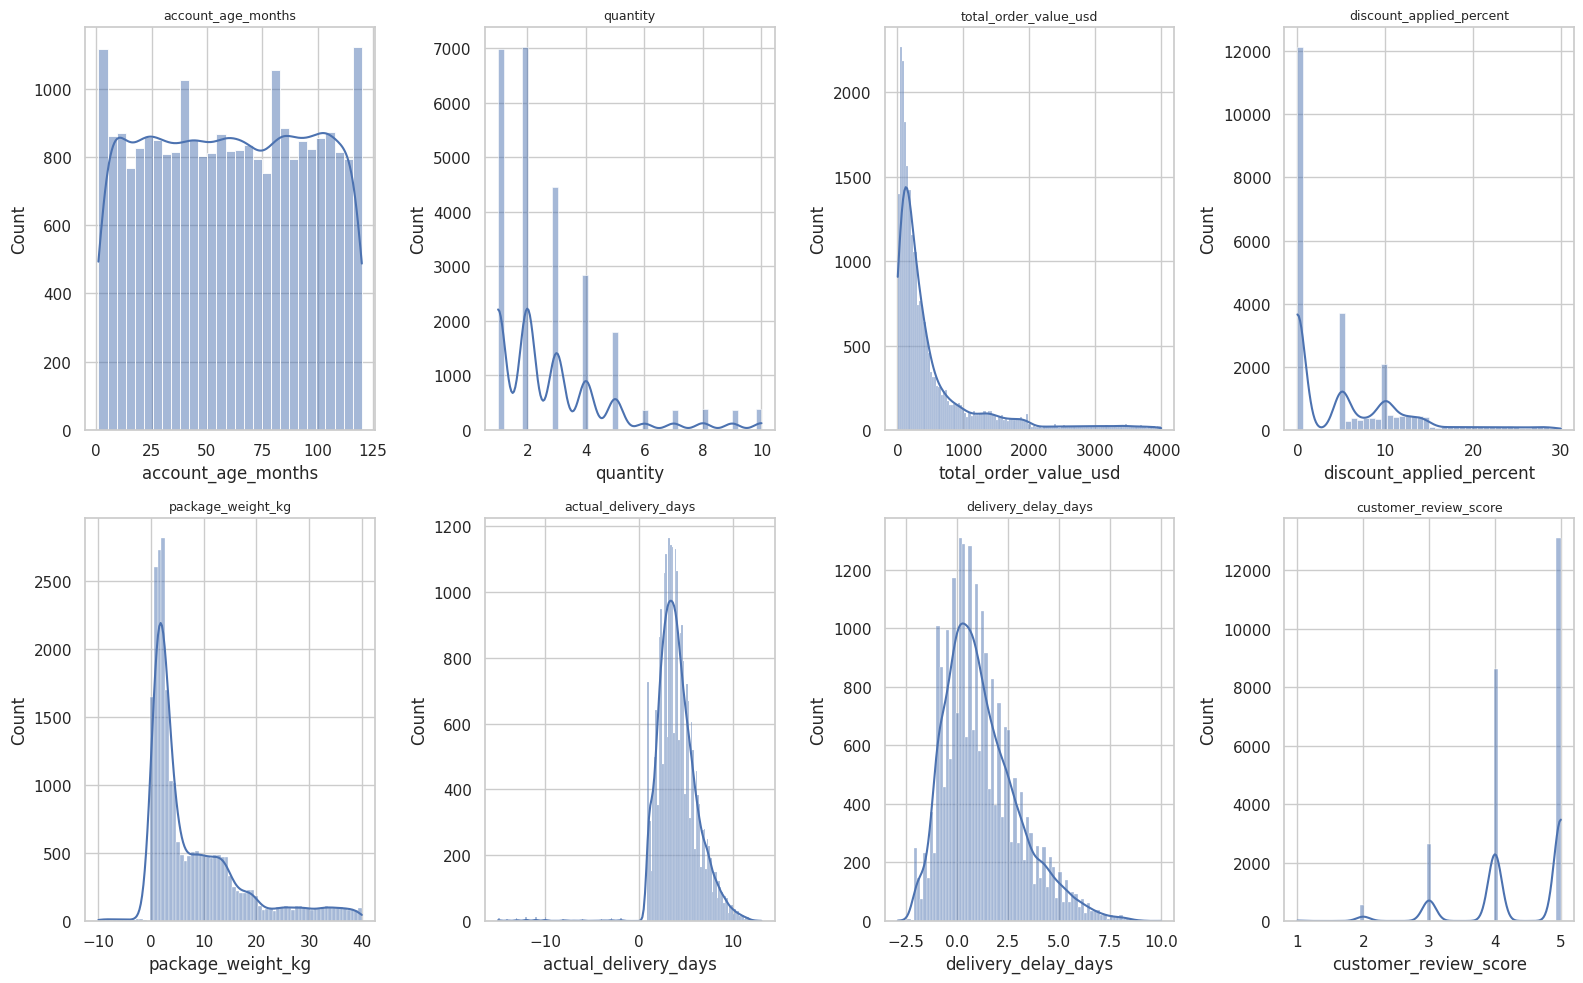

In [ ]:
# Se grafica histogramas para las variables numéricas que no evidencian "aplastamiento" del Boxplot

cols_num2 = ['account_age_months', 'quantity',
            'total_order_value_usd', 'discount_applied_percent',
            'package_weight_kg', 'actual_delivery_days',
            'delivery_delay_days', 'customer_review_score']

fig, axes = plt.subplots(2, 4, figsize=(16, 10))
for ax, col in zip(axes.flat, cols_num2):
    sns.histplot(df_raw[col], kde=True, ax=ax)
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.show()

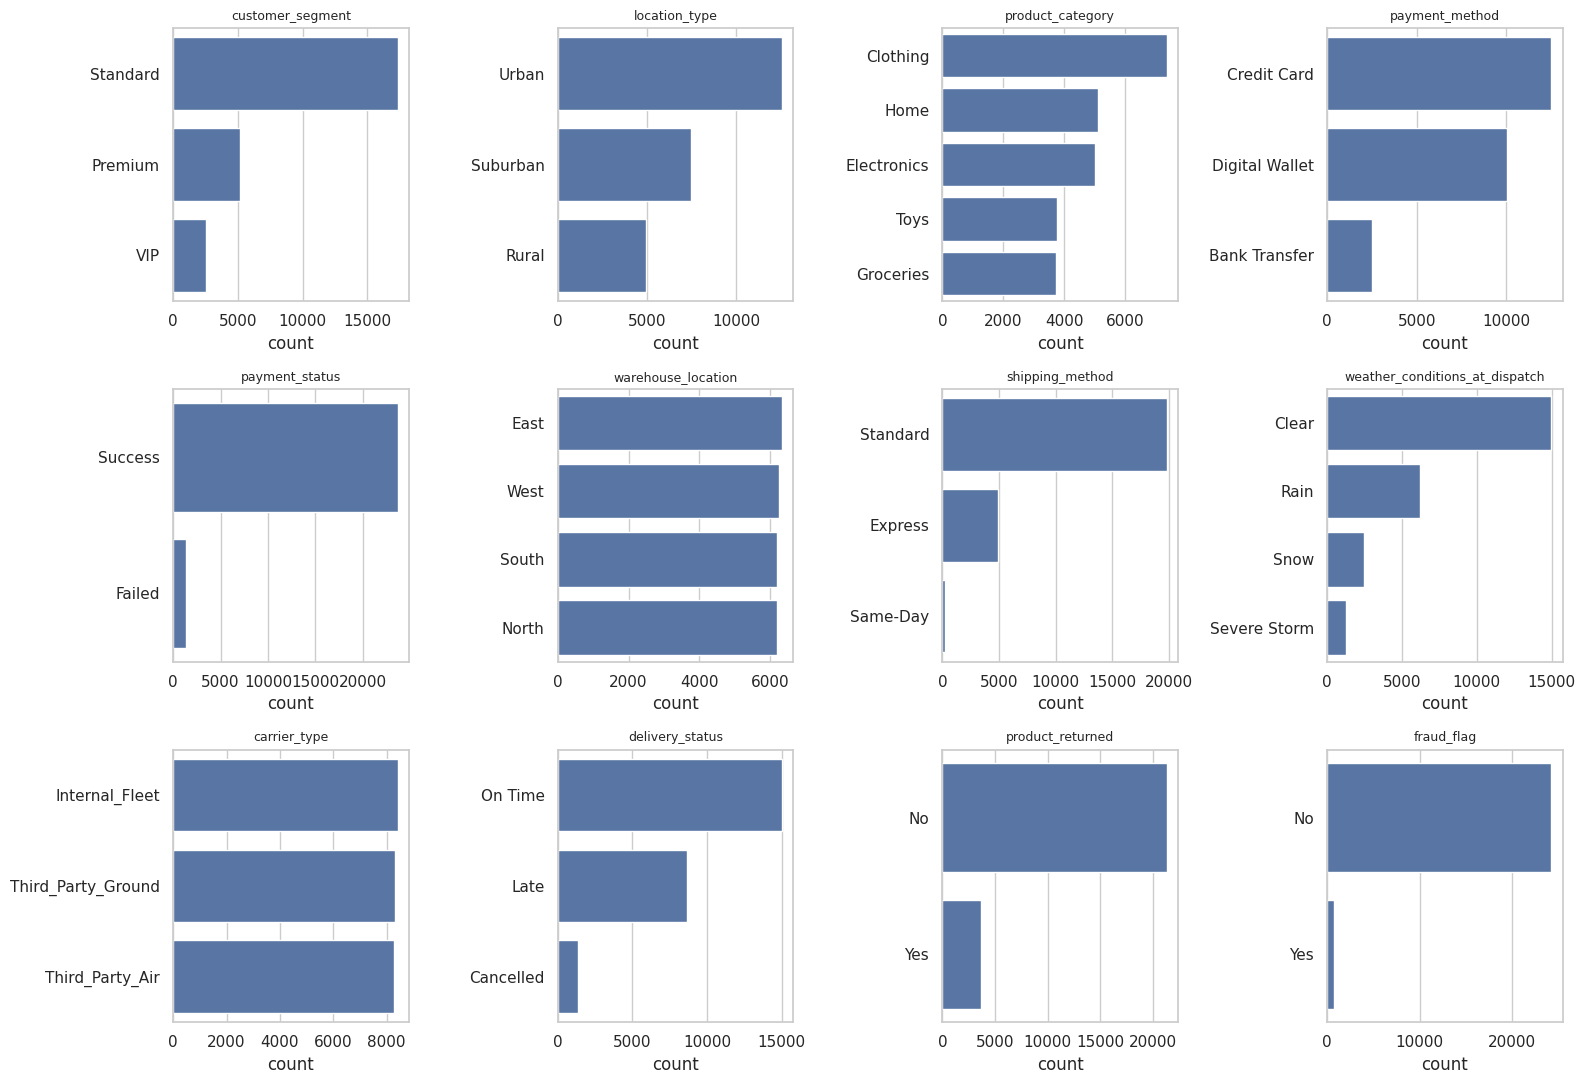

In [ ]:
# Se grafica histograma para variables categoricas

fig, axes = plt.subplots(3, 4, figsize=(16, 11))
for ax, col in zip(axes.flat, cols_cat):
    sns.countplot(data=df_raw, y=col, order=df_raw[col].value_counts().index, ax=ax)
    ax.set_title(col, fontsize=9)
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
#Se valida en detalle el porcentaje por categoría de la varible Objetivo "fraud_flag"

print("=== Distribución de la variable objetivo ===")
target_counts = df_raw['fraud_flag'].value_counts()
target_pct = df_raw['fraud_flag'].value_counts(normalize=True) * 100
resumen_target = pd.DataFrame({"conteo": target_counts, "porcentaje": target_pct.round(2)})
print(resumen_target)

=== Distribución de la variable objetivo ===
            conteo  porcentaje
fraud_flag                    
No           24234       96.94
Yes            766        3.06


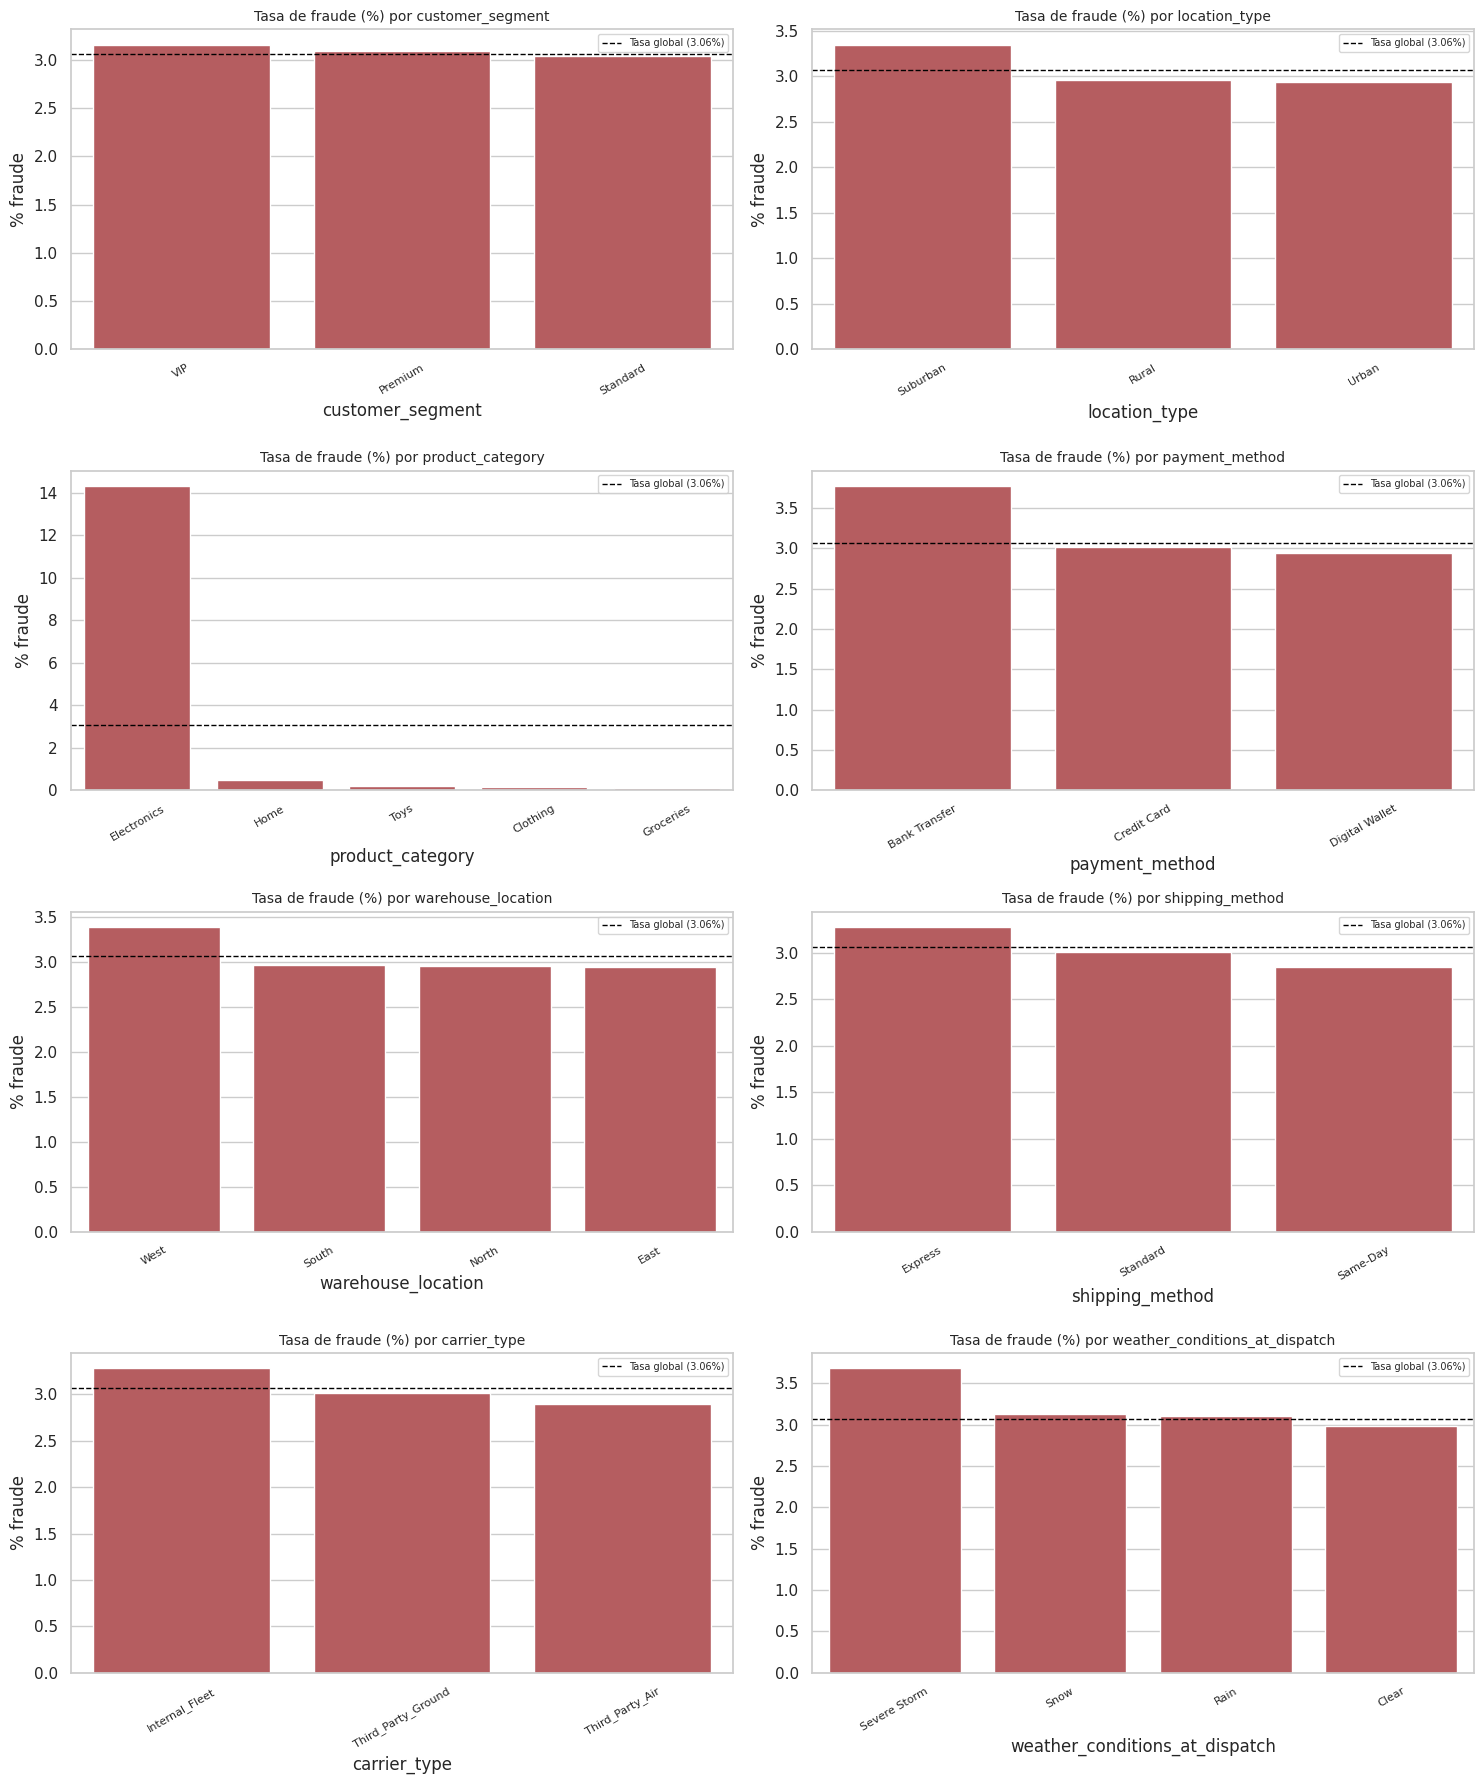

In [ ]:
# --- Gráficos de barras para variables categóricas: distribución y tasa de fraude por categoría ---
cat_cols_business = ["customer_segment", "location_type", "product_category", "payment_method",
                     "warehouse_location", "shipping_method", "carrier_type",
                     "weather_conditions_at_dispatch"]

fig, axes = plt.subplots(4, 2, figsize=(15, 18))
df_tmp = df_raw.copy()
df_tmp["fraud_bin"] = (df_tmp["fraud_flag"] == "Yes").astype(int)

for ax, col in zip(axes.flat, cat_cols_business):
    tasa = df_tmp.groupby(col)["fraud_bin"].mean().sort_values(ascending=False) * 100
    sns.barplot(x=tasa.index, y=tasa.values, ax=ax, color="#C44E52")
    ax.axhline(df_tmp["fraud_bin"].mean() * 100, color="black", linestyle="--", linewidth=1,
               label="Tasa global (3.06%)")
    ax.set_title(f"Tasa de fraude (%) por {col}", fontsize=10)
    ax.set_ylabel("% fraude")
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

**Interpretación de negocio:** este gráfico es clave para el problema de fraude: permite ver qué categorías se desvían de la tasa global de 3.06%. Variables donde la tasa de fraude es prácticamente plana entre categorías (cercana a la línea punteada en todas las barras) aportan poca señal discriminativa y son candidatas a excluirse o a recibir menor peso; variables con diferencias marcadas entre categorías son señales de riesgo útiles para el modelo tales como: `product_category`: `Electronics` que evidencia una alta tasa de fraude

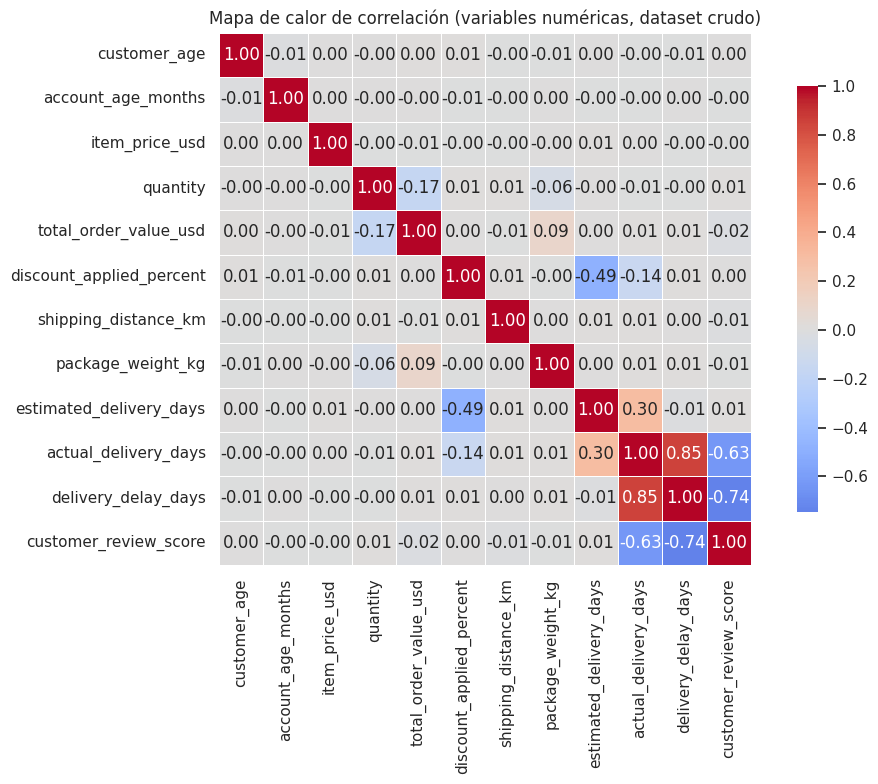

In [ ]:
# --- Mapa de calor de correlación entre variables numéricas ---
plt.figure(figsize=(11, 8))
corr = df_raw[cols_num].corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Mapa de calor de correlación (variables numéricas, dataset crudo)")
plt.tight_layout()
plt.show()

**Interpretación de negocio y técnica del mapa de calor:** se observa una correlación positivia fuerte y esperable entre `estimated_delivery_days`/`actual_delivery_days`/`delivery_delay_days` (estas tres están relacionadas casi por definición: `delay ≈ actual − estimated`).

También una correlación fuerte negativa entre `delivery_delay_days`, `actual_delivery_days` y`customer_review_score` lo cual tiene sentido, entre mas demoras en entregas, peor es la calificación del cliente.


In [ ]:
#Se verifica la relación entre las columnas 'actual_delivery_days', 'estimated_delivery_days' y 'delivery_delay_days'

# Recalculamos el retraso a partir de sus dos componentes
delay_calc = df_raw['actual_delivery_days'] - df_raw['estimated_delivery_days']

# Filas donde el retraso registrado NO coincide con actual - estimated (tolerancia por redondeo)
no_coincide = (df_raw['delivery_delay_days'] - delay_calc).abs() > 0.01

print(f"Filas donde el retraso registrado NO coincide con actual - estimated {no_coincide.sum()} "
      f"({no_coincide.mean():.2%})")

Filas donde el retraso registrado NO coincide con actual - estimated 100 (0.40%)


## **EDA automático sobre los datos crudos (sin limpieza)**

Complementamos el EDA manual con un perfilamiento automático usando `ydata-profiling`, y comparamos explícitamente ambos enfoques.

In [ ]:
!pip install ydata-profiling

try:
    from ydata_profiling import ProfileReport
    HAS_YDATA_PROFILING = True
except ImportError:
    HAS_YDATA_PROFILING = False

if HAS_YDATA_PROFILING:
    try:
        profile = ProfileReport(
            df_raw,
            title="Perfilamiento automático - ecommerce_logistics.csv",
            minimal=True,  # modo 'minimal' para mantener el tiempo de ejecución razonable con 25,000 filas
            explorative=False,
        )
        profile.to_file("eda_automatico_ydata_profiling.html")
        print("Reporte de EDA automático generado y guardado en 'eda_automatico_ydata_profiling.html'.")
        try:
            profile.to_notebook_iframe()
        except Exception:
            print("(No se pudo renderizar el iframe embebido en este entorno; abre el archivo .html generado para verlo.)")
    except Exception as e:
        print(f"[Aviso] Ocurrió un error generando el perfil automático: {e}")
        HAS_YDATA_PROFILING = False
else:
    print("ydata-profiling no está disponible en este entorno; se documenta el análisis comparativo igualmente abajo.")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 26/26 [00:01<00:00, 21.41it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Reporte de EDA automático generado y guardado en 'eda_automatico_ydata_profiling.html'.


## **Comparación EDA manual vs. EDA automático**

- **Estadísticas descriptivas**: calculadas a la medida (media, mediana, moda, IQR, percentiles) con foco en las variables de negocio relevantes. Mientras que el EDA automático genera automáticamente un conjunto más amplio de estadísticas (incluye asimetría, curtosis, valores únicos) para todas las columnas sin necesidad de programar cada métrica.
- **Detección de outliers**: se calculó explícitamente el límite superior e inferior por variable por fuera de los cuales se consideraba presencia de outliers y se interpretó su relevancia para el modelo de fraude. Mientras que el EDA automático señala alertas genéricas de "high correlation", "skewness" o "zeros", pero no interpreta el significado de negocio del outlier (p. ej. no sabe que 982 años es imposible; solo ve un valor extremo estadístico).
- **Correlaciones**: Mapa de calor enfocado en variables numéricas relevantes, interpretado en el contexto de fraude/logística. Mientras que el EDA automático calcula automáticamente varias métricas de correlación (Pearson, Spearman, Cramér's V para categóricas) y advierte de columnas altamente correlacionadas.
- **Duplicados / nulos**: se verificó explícitamente `order_id` duplicado (no detectado por `df.duplicated()` estándar). Mientras que el EDA automático reporta duplicados de fila completa y conteo de nulos, pero no detecta automáticamente duplicidad de una clave de negocio específica como `order_id` (hay que decírselo).
- **Interpretación de negocio**: Cada gráfico/estadística se conecta explícitamente con el problema de fraude (tasa de fraude por categoría, relación entre variables logísticas). Mientras que el EDA automático no tiene contexto de negocio: solo describe la forma estadística de los datos.
- **Velocidad de desarrollo** más lento de construir (hay que programar cada análisis), pero totalmente dirigido a las preguntas que importan. Mientras que el EDA automático es mucho más rápido de generar (una sola línea de código para un perfil completo), ideal como primer barrido o "checklist" de calidad de datos.

- **Conclusión de la comparación:** los dos enfoques son complementarios, no sustitutos. El EDA automático es excelente como primer barrido rápido y exhaustivo de calidad de datos (nulos, tipos, correlaciones brutas, alertas de sesgo estadístico) y como red de seguridad para no pasar por alto ninguna columna. El EDA manual es indispensable para traducir esos hallazgos estadísticos en decisiones de negocio y de modelado (qué outlier es un error de captura vs. un valor válido, qué variable categórica realmente discrimina fraude, qué transformación aplicar y por qué).

## **Comprensión del dataset**

El dataset `ecommerce_logistics.csv` contiene **25,000 filas y 26 columnas**, cada una representando una orden de compra. A alto nivel, las columnas se agrupan en:

- **Identificadores:** `customer_id`, `order_id`.
- **Perfil de cliente:** `customer_age`, `account_age_months`, `customer_segment`, `location_type`.
- **Detalle de la orden / producto:** `product_category`, `item_price_usd`, `quantity`, `total_order_value_usd`, `discount_applied_percent`.
- **Pago:** `payment_method`, `payment_status`.
- **Logística / envío:** `warehouse_location`, `shipping_distance_km`, `package_weight_kg`, `shipping_method`, `weather_conditions_at_dispatch`, `carrier_type`, `estimated_delivery_days`.
- **Resultado posterior al despacho (potencial fuga de datos si se usan como *features*):** `actual_delivery_days`, `delivery_delay_days`, `delivery_status`, `customer_review_score`, `product_returned`.
- **Variable objetivo:** `fraud_flag` (Yes/No).

## **Diagnóstico inicial:**

Nos brinda las pautas para realizar la limpieza de los datos.

- **Espacios en blanco / nulos:** no se detectan valores nulos explícitos (`NaN`) en ninguna columna.
- **Duplicados:** no hay filas 100% duplicadas, pero sí se detecta **un `order_id` duplicado** (dos órdenes distintas comparten el mismo identificador).
- **Inconsistencias:** valores imposibles en `customer_age` (hasta 982 años), `item_price_usd` (hasta ~USD 9.9 millones), `shipping_distance_km` (hasta ~971,235 km), `package_weight_kg` (valores negativos) y `actual_delivery_days` (valores negativos), `estimated_delivery_days` (8 outliers que aplastan el Boxplot). Además, `total_order_value_usd` **no coincide** con `item_price_usd × quantity × (1 - discount_applied_percent/100)` para una parte relevante de las filas. Sin embargo, se identifica que `total_order_value_usd` **coincide** con `item_price_usd × quantity`, es decir sin aplicar el descuento.
- **Textos mal escritos o incompletos:** las columnas categóricas (`customer_segment`, `payment_method`, `shipping_method`, etc.) tienen catálogos limpios y consistentes (sin errores tipográficos ni variantes de mayúsculas/minúsculas).
- **Columnas íntimamente relacionadas:** `item_price_usd`, `quantity`, `discount_applied_percent` y `total_order_value_usd` están relacionadas por una fórmula determinística; `estimated_delivery_days`/`actual_delivery_days`/`delivery_delay_days` también están relacionadas entre sí (`delivery_delay_days ≈ actual − estimated`).
- **Variable Objetivo**: `fraud_flag` solo el 3.06% de las órdenes son fraudulentas. Este fuerte desbalance de clases es la razón central por la que NO usaremos 'accuracy' como métrica principal de desempeño, y por la que emplearemos class_weight='balanced' en el modelado.

## **Particionamiento del dataset (train / validation / test)**

Particionamos el dataset antes de calcular cualquier estadístico de limpieza, codificación o escalamiento. Todo ajuste (percentiles de capping, medias/medianas para imputar, parámetros de los encoders y de los scalers) se calculará únicamente sobre el conjunto de entrenamiento y luego se aplicará a validación y prueba, evitando así la fuga de datos.

**Proporciones elegidas:** 60% entrenamiento / 20% validación / 20% prueba. Justificación: con 25,000 filas mantenemos un conjunto de entrenamiento amplio (15,000 filas) y aun así dejamos 5,000 filas para validación (ajuste de hiperparámetros/umbral de decisión) y 5,000 para prueba final (evaluación honesta, usada una sola vez). Dado el desbalance de clases (3.06%), cada partición seguirá teniendo suficientes ejemplos positivos (~150 casos de fraude en test) para una evaluación razonable gracias al muestreo estratificado.

Se usa `random_state = 42` en ambas divisiones para que el experimento sea 100% reproducible.

In [ ]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

# Partición estratificada 60/20/20 sobre la variable objetivo, usando únicamente el índice
# y la etiqueta (esto NO constituye fuga de datos: se permite estratificar por el target al
# particionar, ya que no se usa ninguna otra información del dataset en este paso).
train_idx, temp_idx = train_test_split(
    df_raw.index,
    test_size=0.40,
    stratify=df_raw["fraud_flag"],
    random_state=RANDOM_STATE
)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=df_raw.loc[temp_idx, "fraud_flag"],
    random_state=RANDOM_STATE
)

print(f"Train: {len(train_idx)} filas ({len(train_idx)/len(df_raw):.1%})")
print(f"Validation: {len(val_idx)} filas ({len(val_idx)/len(df_raw):.1%})")
print(f"Test: {len(test_idx)} filas ({len(test_idx)/len(df_raw):.1%})")

print("\nProporción de fraude en cada partición (verificamos que la estratificación funcionó):")
for nombre, idx in [("Train", train_idx), ("Validation", val_idx), ("Test", test_idx)]:
    tasa = (df_raw.loc[idx, "fraud_flag"] == "Yes").mean()
    print(f"  {nombre}: {tasa:.4%}")

Train: 15000 filas (60.0%)
Validation: 5000 filas (20.0%)
Test: 5000 filas (20.0%)

Proporción de fraude en cada partición (verificamos que la estratificación funcionó):
  Train: 3.0667%
  Validation: 3.0600%
  Test: 3.0600%


In [ ]:
# Copias físicas de cada partición, tal como quedaron tras el particionamiento (sin limpiar aún)
train_df = df_raw.loc[train_idx].copy()
val_df   = df_raw.loc[val_idx].copy()
test_df  = df_raw.loc[test_idx].copy()

# Columnas de identificación (sin valor predictivo) y columnas que constituyen fuga de datos
# porque solo se conocen DESPUÉS del despacho / de la entrega (no estarían disponibles al
# momento de decidir si una orden es fraudulenta)
ID_COLS = ["customer_id", "order_id"]
LEAKAGE_COLS = ["actual_delivery_days", "delivery_delay_days", "delivery_status",
                "customer_review_score", "product_returned"]

print("Columnas de identificación excluidas:", ID_COLS)
print("Columnas de fuga de datos (posteriores al evento) excluidas:", LEAKAGE_COLS)

Columnas de identificación excluidas: ['customer_id', 'order_id']
Columnas de fuga de datos (posteriores al evento) excluidas: ['actual_delivery_days', 'delivery_delay_days', 'delivery_status', 'customer_review_score', 'product_returned']


## **Limpieza y preprocesamiento**

Construimos dos versiones del dataset a partir de las mismas 3 particiones (train/val/test), para poder comparar honestamente el efecto de un buen preprocesamiento:

- **Escenario A — dataset "sucio"**: limpieza mínima indispensable para que el modelo compile (excluir identificadores y columnas de fuga de datos, codificar categóricas de forma simple). No se tratan outliers, no se corrigen inconsistencias, no se escala.
- **Escenario B — dataset limpio**: tratamiento completo de outliers/inconsistencias, corrección de columnas inconsistentes, codificación cuidadosa, selección de variables basada en evidencia y escalamiento justificado.

En ambos escenarios se excluyen los mismos ID_COLS y LEAKAGE_COLS: no tendría sentido de negocio permitir que el modelo "haga trampa" usando información que solo existe después del despacho, ni siquiera en el escenario "sucio" — la suciedad que queremos comparar es la de calidad de datos (outliers, inconsistencias, escalas), no la de fuga temporal de información, que sería un error conceptual en cualquier escenario.



### **Escenario A — Dataset "sucio" (limpieza mínima)**

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

def preparar_dataset_sucio(df):
    '''Limpieza mínima indispensable: excluye IDs y columnas de fuga, mapea el target.
    Deliberadamente NO trata outliers, NO corrige inconsistencias y NO escala nada.'''
    d = df.drop(columns=ID_COLS + LEAKAGE_COLS).copy()
    d["fraud_flag"] = d["fraud_flag"].map({"No": 0, "Yes": 1})
    return d

sucio_train = preparar_dataset_sucio(train_df)
sucio_val   = preparar_dataset_sucio(val_df)
sucio_test  = preparar_dataset_sucio(test_df)

# Codificación mínima: Ordinal/Label Encoding "rápido y sucio" ajustado SOLO en train.
# (Nota crítica: esto impone un orden artificial a variables nominales sin orden real,
#  p. ej. product_category; es intencional para representar una limpieza mínima/deficiente,
#  y se contrasta más adelante con la codificación adecuada del escenario limpio).
cat_cols_sucio = sucio_train.select_dtypes(include="object").columns.tolist()
print("Columnas categóricas codificadas con Ordinal Encoding 'rápido':", cat_cols_sucio)

ord_enc_sucio = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
ord_enc_sucio.fit(sucio_train[cat_cols_sucio])

for d in (sucio_train, sucio_val, sucio_test):
    d[cat_cols_sucio] = ord_enc_sucio.transform(d[cat_cols_sucio])

X_train_sucio = sucio_train.drop(columns="fraud_flag")
X_val_sucio   = sucio_val.drop(columns="fraud_flag")
X_test_sucio  = sucio_test.drop(columns="fraud_flag")
y_train = sucio_train["fraud_flag"]
y_val   = sucio_val["fraud_flag"]
y_test  = sucio_test["fraud_flag"]

print(f"\nDataset sucio listo. X_train: {X_train_sucio.shape}, X_val: {X_val_sucio.shape}, X_test: {X_test_sucio.shape}")
print("¿Quedan valores no numéricos?", (X_train_sucio.dtypes == "object").any())
X_train_sucio.describe().T[["min", "max", "mean"]]

Columnas categóricas codificadas con Ordinal Encoding 'rápido': ['customer_segment', 'location_type', 'product_category', 'payment_method', 'payment_status', 'warehouse_location', 'shipping_method', 'weather_conditions_at_dispatch', 'carrier_type']

Dataset sucio listo. X_train: (15000, 18), X_val: (5000, 18), X_test: (5000, 18)
¿Quedan valores no numéricos? False


,min,max,mean
customer_age,18.00,982.00,41.208467
account_age_months,1.00,120.00,60.573800
customer_segment,0.00,2.00,0.902467
location_type,0.00,2.00,1.307800
product_category,0.00,4.00,1.712333
item_price_usd,5.00,9915889.74,12508.088657
quantity,1.00,10.00,2.819333
total_order_value_usd,5.30,3998.68,535.448665
discount_applied_percent,0.00,30.00,5.496400
payment_method,0.00,2.00,1.297667


 En la tabla anterior se observa que siguen presentes las anomalías originales: edades hasta ~982 (columna `customer_age`, `max`), pesos de productos negativos (`package_weight_kg`, `min`), entre otras anomalías identificadas en el EDA. Esto es deseable para implementar el modelo bajo el Escenario A - datos sucios (limpieza mínima)

### **Escenario B — Dataset limpio (tratamiento completo)**

Aplicamos las reglas de limpieza completa únicamente con estadísticos del conjunto de entrenamiento, y las replicamos sobre validación y prueba, para evitar fuga de datos.

In [ ]:
# --- Reglas de limpieza fijas por conocimiento de negocio (no dependen de estadísticos del train,
#     por lo que no hay riesgo de fuga al aplicarlas igual en las 3 particiones) ---
EDAD_MAX_PLAUSIBLE = 100          # ninguna persona registrada como cliente debe superar esta edad
DIST_MAX_PLAUSIBLE_KM = 2000      # envíos nacionales/regionales; distancias mayores se consideran error de captura

def limpieza_basica(df):
    d = df.copy()
    # 1) Edades imposibles -> se eliminan filas (no se puede saber la edad real)
    d = d[d["customer_age"] <= EDAD_MAX_PLAUSIBLE]
    # 2) Peso de paquete negativo -> corrección de signo (error de captura, la magnitud es válida)
    d["package_weight_kg"] = d["package_weight_kg"].abs()
    # 3) Tiempos de entrega negativos -> se eliminan filas (inconsistencia lógica: no se puede
    #    entregar en tiempo negativo). Se aplica sobre 'actual_delivery_days' como filtro de calidad
    #    de fila, aunque esa columna NO se use como feature (es leakage), porque señala un registro
    #    corrupto en general.
    d = d[d["actual_delivery_days"] > 0]
    # 4) Distancias de envío irreales -> se eliminan filas por encima de un umbral plausible fijo
    d = d[d["shipping_distance_km"] <= DIST_MAX_PLAUSIBLE_KM]
    return d

limpio_train = limpieza_basica(train_df)
limpio_val   = limpieza_basica(val_df)
limpio_test  = limpieza_basica(test_df)

# Igual que en el escenario "sucio", excluimos identificadores y columnas de fuga de datos
# posteriores al evento. Se hace ANTES de cualquier codificación/selección/escalamiento.
limpio_train = limpio_train.drop(columns=ID_COLS + LEAKAGE_COLS)
limpio_val   = limpio_val.drop(columns=ID_COLS + LEAKAGE_COLS)
limpio_test  = limpio_test.drop(columns=ID_COLS + LEAKAGE_COLS)

print("Filas antes de limpieza -> después de limpieza:")
for nombre, antes, despues in [("train", train_df, limpio_train), ("val", val_df, limpio_val), ("test", test_df, limpio_test)]:
    print(f"  {nombre}: {len(antes)} -> {len(despues)}  ({len(antes)-len(despues)} filas removidas, "
          f"{(len(antes)-len(despues))/len(antes):.2%})")

Filas antes de limpieza -> después de limpieza:
  train: 15000 -> 14708  (292 filas removidas, 1.95%)
  val: 5000 -> 4889  (111 filas removidas, 2.22%)
  test: 5000 -> 4894  (106 filas removidas, 2.12%)


In [ ]:
# --- Corrección de la inconsistencia entre total_order_value_usd y su cálculo esperado ---
for d in (limpio_train, limpio_val, limpio_test):
    d["total_order_value_calc"] = (
        d["item_price_usd"] * d["quantity"] * (1 - d["discount_applied_percent"] / 100)
    )

diff_pct = (
    (limpio_train["total_order_value_usd"] - limpio_train["total_order_value_calc"]).abs()
    / limpio_train["total_order_value_calc"].replace(0, np.nan)
)
print(f"% de filas (train) donde total_order_value_usd difiere >1% del valor recalculado: "
      f"{(diff_pct > 0.01).mean():.2%}")

# Conservamos el valor RECALCULADO (más confiable porque se deriva de columnas ya validadas)
# y descartamos el original, que demostramos inconsistente.
for d in (limpio_train, limpio_val, limpio_test):
    d.drop(columns=["total_order_value_usd"], inplace=True)

print("\nColumna 'total_order_value_usd' (inconsistente) eliminada; se conserva 'total_order_value_calc'.")

% de filas (train) donde total_order_value_usd difiere >1% del valor recalculado: 51.60%

Columna 'total_order_value_usd' (inconsistente) eliminada; se conserva 'total_order_value_calc'.


In [ ]:
# --- Tope máximo de outliers en variables continuas de alto IQR ratio ---
# Los umbrales (percentil 99) se calculan EXCLUSIVAMENTE sobre el conjunto de entrenamiento,
# y se aplican tal cual (mismos valores numéricos) a validación y prueba.
CAP_COLS = ["item_price_usd", "total_order_value_calc"]
caps = {}
for c in CAP_COLS:
    caps[c] = limpio_train[c].quantile(0.99)

print("Umbrales máximos (percentil 99, calculados solo con train):")
for c, v in caps.items():
    print(f"  {c}: {v:,.2f}")

for d in (limpio_train, limpio_val, limpio_test):
    for c, v in caps.items():
        d[c] = d[c].clip(upper=v)

print("\nMáximos tras el umbral definido (train):")
print(limpio_train[CAP_COLS].max())

Umbrales máximos (percentil 99, calculados solo con train):
  item_price_usd: 1,930.57
  total_order_value_calc: 3,453.97

Máximos tras el umbral definido (train):
item_price_usd            1930.5655
total_order_value_calc    3453.9686
dtype: float64


## **Codificación de variables categóricas (One-Hot, Ordinal/Label y Binary Encoding)**

El dataset final para modelar debe quedar completamente numérico. Usamos tres técnicas distintas, cada una justificada por la naturaleza de la variable:

- **Ordinal/Label Encoding para `customer_segment`:** esta variable sí tiene un orden natural de negocio (Standard < Premium < VIP, en términos de valor del cliente), por lo que asignarle un orden numérico (0, 1, 2) es correcto y no introduce una relación falsa (a diferencia de aplicar Ordinal Encoding a una variable puramente nominal, como se hizo por simplicidad en el escenario "sucio").
- **One-Hot Encoding para el resto de variables nominales** (`location_type`, `product_category`, `payment_method`, `payment_status`, `warehouse_location`, `shipping_method`, y `weather_conditions_at_dispatch`, `carrier_type`): son categorías sin orden intrínseco, por lo que One-Hot evita imponer una relación numérica artificial. Se usa `drop_first=True` para evitar la trampa de la variable ficticia (*dummy variable trap*), que generaría multicolinealidad perfecta.
- **Binary Encoding:** no se aplica Binary Encoding sobre `product_category` ya que es la variable nominal con pocas categorías(5). Con solo 5 categorías, One-Hot genera 4 columnas dummy — una cantidad perfectamente manejable — mientras que Binary Encoding generaría ~3 columnas. La ganancia en reducción de dimensionalidad es marginal aquí, por lo que decidimos usar One-Hot para el pipeline final (mayor interpretabilidad de coeficientes). Sin embargo, Binary Encoding sería la elección correcta si esta variable tuviera decenas o cientos de categorías.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# --- Codificación final aplicada al dataset limpio ---
ORDEN_SEGMENTO = {"Standard": 0, "Premium": 1, "VIP": 2}
ONE_HOT_COLS = ["location_type", "product_category", "payment_method", "payment_status",
                "warehouse_location", "shipping_method", "weather_conditions_at_dispatch",
                "carrier_type"]

def codificar_limpio(df, ohe=None, fit=False):
    d = df.copy()
    d["customer_segment"] = d["customer_segment"].map(ORDEN_SEGMENTO)
    d["fraud_flag"] = d["fraud_flag"].map({"No": 0, "Yes": 1})

    if fit:
        ohe = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
        ohe.fit(d[ONE_HOT_COLS])

    encoded = ohe.transform(d[ONE_HOT_COLS])
    encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(ONE_HOT_COLS), index=d.index)

    d = d.drop(columns=ONE_HOT_COLS)
    d = pd.concat([d, encoded_df], axis=1)
    return d, ohe

limpio_train_enc, ohe_fitted = codificar_limpio(limpio_train, fit=True)
limpio_val_enc, _   = codificar_limpio(limpio_val, ohe=ohe_fitted, fit=False)
limpio_test_enc, _  = codificar_limpio(limpio_test, ohe=ohe_fitted, fit=False)

print(f"Dataset limpio codificado: {limpio_train_enc.shape[1] - 1} variables predictoras "
      f"(antes de selección de variables), completamente numérico.")
print("¿Quedan columnas no numéricas?", (limpio_train_enc.dtypes == "object").any())
limpio_train_enc.head()

Dataset limpio codificado: 29 variables predictoras (antes de selección de variables), completamente numérico.
¿Quedan columnas no numéricas? False


,customer_age,account_age_months,customer_segment,item_price_usd,quantity,discount_applied_percent,shipping_distance_km,package_weight_kg,estimated_delivery_days,fraud_flag,...,warehouse_location_North,warehouse_location_South,warehouse_location_West,shipping_method_Same-Day,shipping_method_Standard,weather_conditions_at_dispatch_Rain,weather_conditions_at_dispatch_Severe Storm,weather_conditions_at_dispatch_Snow,carrier_type_Third_Party_Air,carrier_type_Third_Party_Ground
9173,22,5,2,27.46,4,18.6,265.3,1.50,2.0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
12772,50,50,1,42.91,5,13.8,206.4,1.54,2.0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16042,26,49,0,114.73,4,0.0,560.0,2.79,3.0,0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
10182,51,80,0,53.97,3,0.0,806.1,2.82,3.0,0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
10223,46,23,1,24.16,2,8.6,231.5,4.22,3.0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


## **Selección de variables**

Evaluamos con evidencia cuantitativa qué variables conservar, usando estadisticos como: correlación, VIF, multicolinealidad, relevancia categórica, entre otros.



### **Correlación y VIF entre variables numéricas continuas**

El VIF (Variance Inflation Factor, factor de inflación de la varianza) es un estadístico que mide la multicolinealidad: cuánto se relaciona linealmente una variable predictora con las demás variables predictoras de un modelo. En otras palabras, te dice si una columna aporta información nueva o si es prácticamente una combinación de las otras.

Cómo se calcula. Para cada variable, se hace una regresión lineal usándola como objetivo y todas las demás predictoras como entradas. De ahí sale un R² (qué tan bien las otras la explican) y el VIF es:

VIF= 1/(1-R²)

Si las otras variables explican muy poco de esa columna, R² es bajo y el VIF se acerca a 1. Si la explican casi por completo, R² se acerca a 1 y el VIF se dispara.

Interpretación:

- VIF ≈ 1 → sin multicolinealidad, la variable es independiente.
- VIF entre 1 y 5 → correlación moderada, normalmente aceptable.
- VIF > 5 → multicolinealidad alta; conviene revisar o eliminar la variable.

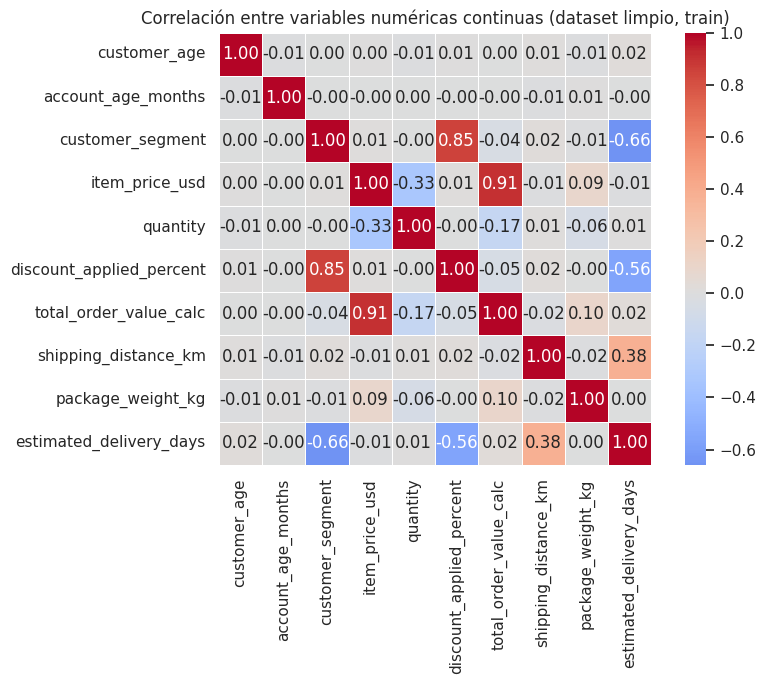

In [ ]:
CONT_COLS = ["customer_age", "account_age_months", "customer_segment", "item_price_usd",
             "quantity", "discount_applied_percent", "total_order_value_calc",
             "shipping_distance_km", "package_weight_kg", "estimated_delivery_days"]

plt.figure(figsize=(9, 7))
sns.heatmap(limpio_train_enc[CONT_COLS].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5)
plt.title("Correlación entre variables numéricas continuas (dataset limpio, train)")
plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calcular_vif(df, cols):
    X = df[cols].copy()
    X = X.assign(const=1)  # VIF requiere una constante
    vif_data = []
    for i, col in enumerate(cols):
        vif = variance_inflation_factor(X.values, i)
        vif_data.append({"variable": col, "VIF": vif})
    return pd.DataFrame(vif_data).sort_values("VIF", ascending=False).reset_index(drop=True)

tabla_vif = calcular_vif(limpio_train_enc, CONT_COLS)
tabla_vif

,variable,VIF
0,item_price_usd,7.169073
1,total_order_value_calc,6.605299
2,customer_segment,4.703389
3,discount_applied_percent,3.665853
4,estimated_delivery_days,2.427354
5,shipping_distance_km,1.373286
6,quantity,1.270530
7,package_weight_kg,1.012482
8,customer_age,1.001404
9,account_age_months,1.000308


**Interpretación y decisión:** un VIF por encima de ~5 indica multicolinealidad severa. Es esperable que `total_order_value_calc` muestre el VIF más alto, porque por construcción es una combinación determinística de `item_price_usd`, `quantity` y `discount_applied_percent` (`total = precio × cantidad × (1 − descuento/100)`) — no aporta información nueva, solo redundancia. **Decisión:** eliminamos `total_order_value_calc` del conjunto de variables predictoras y conservamos sus tres componentes por separado, que son más interpretables individualmente y evitan inflar artificialmente la importancia de esa dimensión de "valor de la orden". El resto de variables continuas presenta VIF inferiores a 5, por lo que se conservan todas.

In [ ]:
COLS_A_ELIMINAR_VIF = ["total_order_value_calc"]
print("Variables eliminadas por multicolinealidad (VIF alto):", COLS_A_ELIMINAR_VIF)

Variables eliminadas por multicolinealidad (VIF alto): ['total_order_value_calc']


### **Relevancia de variables categóricas frente al fraude**

Retomamos los gráficos de tasa de fraude por categoría y los formalizamos con una prueba de independencia Chi-cuadrado: si la categoría de una variable no está asociada de forma estadísticamente significativa con `fraud_flag`, es una candidata a eliminarse por bajo poder predictivo (reduce dimensionalidad sin perder señal real).

In [ ]:
from scipy.stats import chi2_contingency

cat_vars_a_evaluar = ["location_type", "product_category", "payment_method", "payment_status",
                      "warehouse_location", "shipping_method", "weather_conditions_at_dispatch",
                      "carrier_type", "customer_segment"]

resultados_chi2 = []
for var in cat_vars_a_evaluar:
    serie = train_df.loc[limpio_train.index, var]
    tabla = pd.crosstab(serie, limpio_train["fraud_flag"])
    chi2, p, dof, _ = chi2_contingency(tabla)
    tasa_por_cat = limpio_train.groupby(train_df.loc[limpio_train.index, var])["fraud_flag"].apply(
        lambda s: (s == "Yes").mean()
    )
    resultados_chi2.append({
        "variable": var,
        "chi2": chi2,
        "p_valor": p,
        "significativa_al_5%": p < 0.05,
        "rango_tasa_fraude_pp": (tasa_por_cat.max() - tasa_por_cat.min()) * 100
    })

tabla_chi2 = pd.DataFrame(resultados_chi2).sort_values("p_valor")
tabla_chi2

,variable,chi2,p_valor,significativa_al_5%,rango_tasa_fraude_pp
1,product_category,1581.202516,0.000000,True,14.254737
2,payment_method,5.261253,0.072033,False,1.153054
3,payment_status,3.037945,0.081339,False,1.157276
7,carrier_type,3.258036,0.196122,False,0.626427
0,location_type,1.722262,0.422684,False,0.530853
5,shipping_method,1.628165,0.443046,False,1.759064
6,weather_conditions_at_dispatch,0.493270,0.920367,False,0.468436
4,warehouse_location,0.129347,0.988097,False,0.131983
8,customer_segment,0.020584,0.989761,False,0.047894


**Interpretación y decisión:** las variables con `p_valor` alto (no significativas al 5%) y un rango de tasa de fraude entre categorías muy pequeño (pocos puntos porcentuales) aportan poca señal discriminativa para el fraude — consistente con lo observado visualmente en el EDA Manual, donde todas las variables excepto `product_category` mostraban barras muy cercanas a la tasa global. **Regla de decisión:** se eliminan las columnas One-Hot derivadas de variables con `p_valor >= 0.05`, ya que no hay evidencia de asociación con el fraude en esta muestra.

In [ ]:
vars_no_significativas = tabla_chi2.loc[~tabla_chi2["significativa_al_5%"], "variable"].tolist()
print("Variables categóricas sin asociación significativa con fraud_flag (p >= 0.05):", vars_no_significativas)

# Traducimos esas variables a los nombres de columnas One-Hot que generaron, para eliminarlas del set final
cols_onehot_a_eliminar = [c for c in limpio_train_enc.columns
                          if any(c.startswith(v + "_") for v in vars_no_significativas)]
print("Columnas One-Hot correspondientes a eliminar:", cols_onehot_a_eliminar)

COLUMNAS_FINALES_A_ELIMINAR = COLS_A_ELIMINAR_VIF + cols_onehot_a_eliminar

FEATURES_LIMPIO = [c for c in limpio_train_enc.columns
                   if c not in COLUMNAS_FINALES_A_ELIMINAR + ["fraud_flag"]]

print(f"\nVariables predictoras finales tras selección: {len(FEATURES_LIMPIO)}")
print(FEATURES_LIMPIO)

Variables categóricas sin asociación significativa con fraud_flag (p >= 0.05): ['payment_method', 'payment_status', 'carrier_type', 'location_type', 'shipping_method', 'weather_conditions_at_dispatch', 'warehouse_location', 'customer_segment']
Columnas One-Hot correspondientes a eliminar: ['location_type_Suburban', 'location_type_Urban', 'payment_method_Credit Card', 'payment_method_Digital Wallet', 'payment_status_Success', 'warehouse_location_North', 'warehouse_location_South', 'warehouse_location_West', 'shipping_method_Same-Day', 'shipping_method_Standard', 'weather_conditions_at_dispatch_Rain', 'weather_conditions_at_dispatch_Severe Storm', 'weather_conditions_at_dispatch_Snow', 'carrier_type_Third_Party_Air', 'carrier_type_Third_Party_Ground']

Variables predictoras finales tras selección: 13
['customer_age', 'account_age_months', 'customer_segment', 'item_price_usd', 'quantity', 'discount_applied_percent', 'shipping_distance_km', 'package_weight_kg', 'estimated_delivery_days', '

In [ ]:
# Matrices de variables predictoras (X) y objetivo (y) del ESCENARIO LIMPIO, ya con la
# selección de variables aplicada.  El número de filas difiere del escenario sucio
# porque limpieza_basica() eliminó filas con anomalías -- esto es esperado y correcto: cada
# escenario se evalúa contra SU PROPIA partición de test derivada de las mismas filas originales.
X_train_limpio_raw = limpio_train_enc[FEATURES_LIMPIO].copy()
X_val_limpio_raw   = limpio_val_enc[FEATURES_LIMPIO].copy()
X_test_limpio_raw  = limpio_test_enc[FEATURES_LIMPIO].copy()

y_train_limpio = limpio_train_enc["fraud_flag"].copy()
y_val_limpio   = limpio_val_enc["fraud_flag"].copy()
y_test_limpio  = limpio_test_enc["fraud_flag"].copy()

print(f"X_train_limpio_raw: {X_train_limpio_raw.shape}  |  tasa de fraude: {y_train_limpio.mean():.4%}")
print(f"X_val_limpio_raw:   {X_val_limpio_raw.shape}  |  tasa de fraude: {y_val_limpio.mean():.4%}")
print(f"X_test_limpio_raw:  {X_test_limpio_raw.shape}  |  tasa de fraude: {y_test_limpio.mean():.4%}")

X_train_limpio_raw: (14708, 13)  |  tasa de fraude: 3.0460%
X_val_limpio_raw:   (4889, 13)  |  tasa de fraude: 3.0886%
X_test_limpio_raw:  (4894, 13)  |  tasa de fraude: 3.0650%


## **Escalamiento**

Comparamos `StandardScaler`, `MinMaxScaler`, `RobustScaler` y la transformación logarítmica `log1p` sobre las variables continuas más asimétricas, y justificamos la elección final.

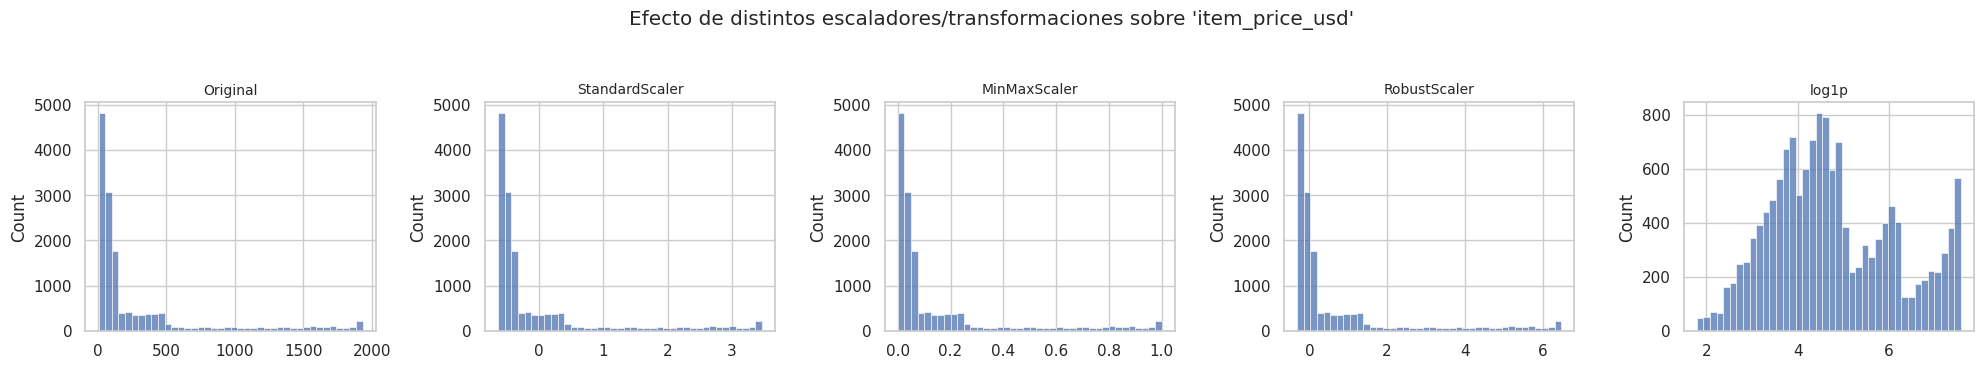

,mean,std,min,max
Original,302.484,469.531,5.000,1930.566
StandardScaler,-0.000,1.000,-0.634,3.468
MinMaxScaler,0.154,0.244,0.000,1.000
RobustScaler,0.738,1.653,-0.309,6.471
log1p,4.758,1.370,1.792,7.566


In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# --- Comparación visual de escaladores sobre 'item_price_usd' (variable con IQR ratio alto) ---
col_demo = "item_price_usd"
valores = X_train_limpio_raw[[col_demo]].values

comparativa = {
    "Original": valores.flatten(),
    "StandardScaler": StandardScaler().fit_transform(valores).flatten(),
    "MinMaxScaler": MinMaxScaler().fit_transform(valores).flatten(),
    "RobustScaler": RobustScaler().fit_transform(valores).flatten(),
    "log1p": np.log1p(valores).flatten(),
}

fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))
for ax, (nombre, datos) in zip(axes, comparativa.items()):
    sns.histplot(datos, bins=40, ax=ax, color="#4C72B0")
    ax.set_title(nombre, fontsize=10)
plt.suptitle(f"Efecto de distintos escaladores/transformaciones sobre '{col_demo}'", y=1.05)
plt.tight_layout()
plt.show()

resumen_escaladores = pd.DataFrame({
    nombre: pd.Series(datos).describe() for nombre, datos in comparativa.items()
}).T
resumen_escaladores[["mean", "std", "min", "max"]].round(3)

**Justificación de la elección de escalamiento:**

- **MinMaxScaler:** se descarta como escalador general porque comprime toda la escala en función de los valores mínimo/máximo — extremadamente sensible a outliers residuales (incluso tras el umbral al percentil 99, un solo valor extremo distorsiona el rango 0-1 para el resto de los datos).
- **StandardScaler:** asume una distribución razonablemente simétrica/normal; como vimos , varias variables (precio, distancia) siguen siendo asimétricas incluso tras el umbral, por lo que la media y desviación estándar quedan influenciadas por la cola residual.
- **`log1p`:** reduce drásticamente la asimetría de variables monetarias/de distancia con colas largas (se aplica **antes** de escalar). Se usa sobre `item_price_usd`, `shipping_distance_km` e `item_price_usd`-derivadas, dado que sus histogramas muestran clara asimetría positiva.
- **RobustScaler:** al usar la mediana y el rango intercuartílico en vez de la media/desviación estándar, es mucho menos sensible a los outliers residuales que persisten tras el umbral del presentil 99. **Se elige como escalador final** para el resto de variables continuas (`customer_age`, `account_age_months`, `quantity`, `discount_applied_percent`, `package_weight_kg`, `estimated_delivery_days`), aplicado **después** del `log1p` en las variables de cola larga.

Todos los ajustes (`fit`) se realizan únicamente sobre `X_train_limpio_raw`, y se reutilizan (`transform`) sobre validación y prueba.

In [ ]:
COLS_LOG = ["item_price_usd", "shipping_distance_km"]
COLS_ROBUST = [c for c in ["customer_age", "account_age_months", "quantity", "discount_applied_percent",
                            "package_weight_kg", "estimated_delivery_days"] if c in X_train_limpio_raw.columns]
# customer_segment ya es ordinal (0,1,2) y las columnas One-Hot ya son binarias (0/1):
# no requieren escalamiento adicional.
COLS_SIN_ESCALAR = [c for c in X_train_limpio_raw.columns if c not in COLS_LOG + COLS_ROBUST]

def aplicar_log1p(X):
    X = X.copy()
    for c in COLS_LOG:
        X[c] = np.log1p(X[c].clip(lower=0))
    return X

X_train_log = aplicar_log1p(X_train_limpio_raw)
X_val_log   = aplicar_log1p(X_val_limpio_raw)
X_test_log  = aplicar_log1p(X_test_limpio_raw)

robust_scaler = RobustScaler()
robust_scaler.fit(X_train_log[COLS_LOG + COLS_ROBUST])

def escalar(X):
    X = X.copy()
    X[COLS_LOG + COLS_ROBUST] = robust_scaler.transform(X[COLS_LOG + COLS_ROBUST])
    return X

X_train_limpio = escalar(X_train_log)
X_val_limpio   = escalar(X_val_log)
X_test_limpio  = escalar(X_test_log)

print("Escalamiento aplicado (log1p + RobustScaler, ajustado solo con train).")
X_train_limpio.describe().T[["mean", "std", "min", "max"]].round(3)

Escalamiento aplicado (log1p + RobustScaler, ajustado solo con train).


,mean,std,min,max
customer_age,0.006,0.670,-1.048,2.143
account_age_months,-0.006,0.574,-0.984,0.967
customer_segment,0.409,0.671,0.000,2.000
item_price_usd,0.106,0.673,-1.352,1.487
quantity,0.273,0.659,-0.333,2.667
discount_applied_percent,0.050,0.687,-0.500,2.500
shipping_distance_km,-0.100,0.770,-4.306,1.352
package_weight_kg,0.400,0.892,-0.392,3.470
estimated_delivery_days,-0.132,0.569,-2.000,2.000
product_category_Electronics,0.199,0.399,0.000,1.000


## **Configuración e implementación del Modelo predictivo**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, classification_report, confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay

def evaluar_modelo(modelo, X_test, y_test, nombre_escenario, mostrar_graficos=True):
    '''Función reutilizable: calcula métricas de clasificación adecuadas para un problema
    binario desbalanceado y, opcionalmente, grafica matriz de confusión y curvas ROC / PR.'''
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    metricas = {
        "escenario": nombre_escenario,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_fraude": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        "recall_fraude": recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        "f1_fraude": f1_score(y_test, y_pred, pos_label=1, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba),
    }

    print(f"=== Resultados: {nombre_escenario} ===")
    print(classification_report(y_test, y_pred, target_names=["No fraude", "Fraude"], zero_division=0))
    print(f"ROC-AUC: {metricas['roc_auc']:.4f}   |   PR-AUC: {metricas['pr_auc']:.4f}")

    if mostrar_graficos:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
                    xticklabels=["Pred: No", "Pred: Sí"], yticklabels=["Real: No", "Real: Sí"])
        axes[0].set_title(f"Matriz de confusión\n{nombre_escenario}")

        RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
        axes[1].set_title("Curva ROC")

        PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[2])
        axes[2].set_title("Curva Precisión-Recall")

        plt.tight_layout()
        plt.show()

    return metricas

### **Modelado predictivo — Escenario A: dataset "sucio"**

**Modelo elegido:** Regresión Logística (`LogisticRegression`), con `class_weight="balanced"` para compensar el desbalance de clases (3.06% de fraude) y `random_state=42` para reproducibilidad. Se elige este modelo (en vez de, por ejemplo, un árbol) precisamente porque es sensible a la escala y a los outliers, lo que nos permite demostrar de forma honesta el efecto real de un buen preprocesamiento al compararlo contra el Escenario B.

Entrenamos sobre `X_train_sucio` (con anomalías sin tratar y codificación mínima) y evaluamos sobre `X_test_sucio`, que nunca fue tocado durante el entrenamiento.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Resultados: Escenario A - Dataset sucio ===
              precision    recall  f1-score   support

   No fraude       1.00      0.93      0.96      4847
      Fraude       0.31      0.92      0.46       153

    accuracy                           0.93      5000
   macro avg       0.65      0.93      0.71      5000
weighted avg       0.98      0.93      0.95      5000

ROC-AUC: 0.9756   |   PR-AUC: 0.7482


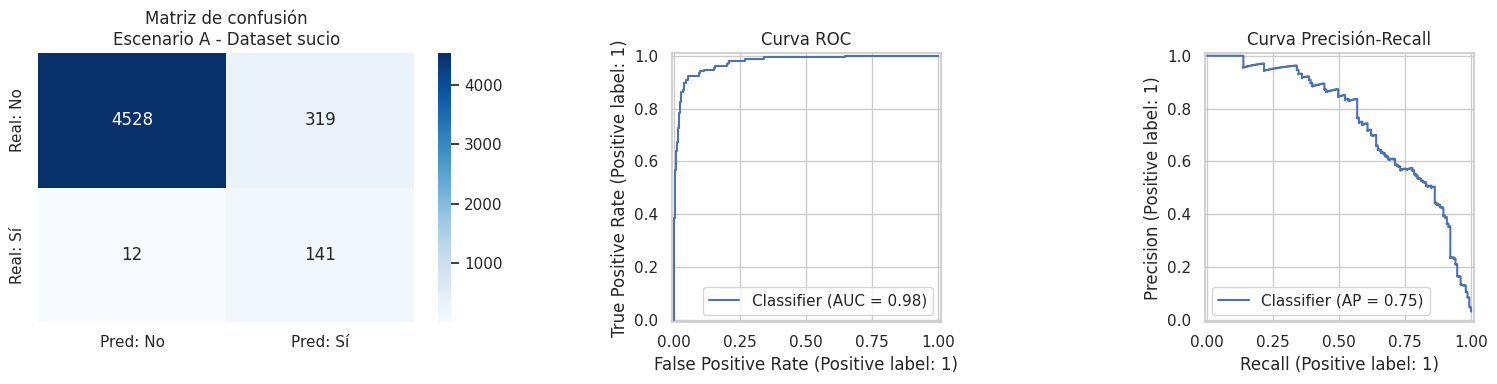

In [ ]:
from sklearn.linear_model import LogisticRegression

modelo_sucio = LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE)
modelo_sucio.fit(X_train_sucio, y_train)

metricas_sucio = evaluar_modelo(modelo_sucio, X_test_sucio, y_test, "Escenario A - Dataset sucio")

**Línea base de referencia (para contextualizar las métricas):** un modelo trivial que siempre prediga "No fraude" obtendría ~96.9% de *accuracy* pero 0% de *recall* sobre el fraude (no detectaría ningún caso), lo cual no tiene ningún valor de negocio. Comparamos siempre contra esta referencia, no contra el 100%.

### **Modelado predictivo — Escenario B: dataset limpio y preprocesado**

Aplicamos exactamente el mismo algoritmo(`LogisticRegression`, mismas variables externas, mismo `random_state`) sobre `X_train_limpio` (outliers tratados, columnas inconsistentes corregidas, codificación completa, variables seleccionadas por evidencia y escalamiento `log1p` + `RobustScaler`), evaluando sobre `X_test_limpio`.

=== Resultados: Escenario B - Dataset limpio ===
              precision    recall  f1-score   support

   No fraude       1.00      0.90      0.95      4744
      Fraude       0.23      0.96      0.37       150

    accuracy                           0.90      4894
   macro avg       0.62      0.93      0.66      4894
weighted avg       0.98      0.90      0.93      4894

ROC-AUC: 0.9722   |   PR-AUC: 0.6367


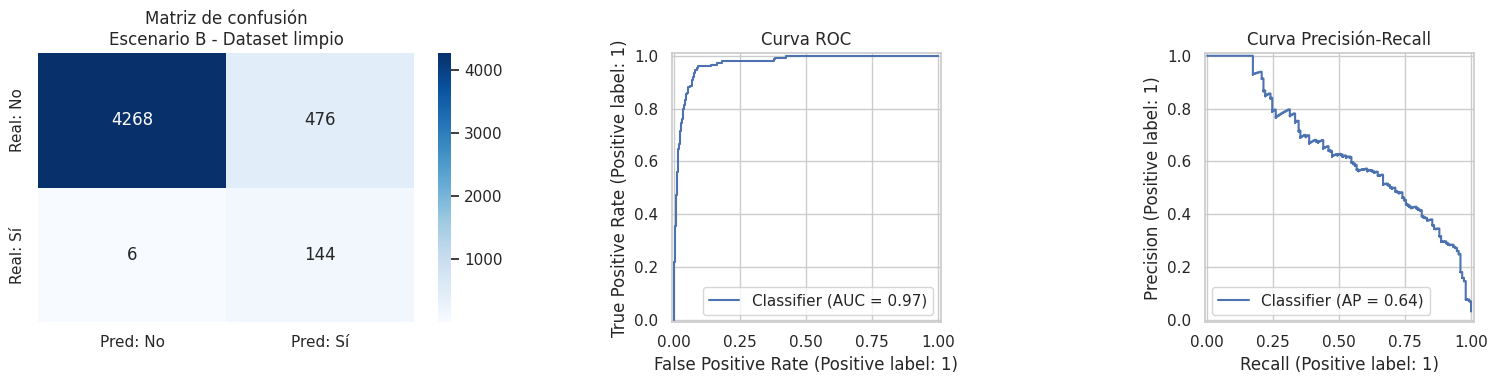

In [ ]:
modelo_limpio = LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE)
modelo_limpio.fit(X_train_limpio, y_train_limpio)

metricas_limpio = evaluar_modelo(modelo_limpio, X_test_limpio, y_test_limpio, "Escenario B - Dataset limpio")

### **Modelo alternativo (Random Forest) sobre el dataset limpio**

Entrenamos también un `RandomForestClassifier` sobre el mismo dataset limpio, para ver si un modelo no lineal captura mejor las interacciones entre variables.

=== Resultados: Extra - Random Forest (dataset limpio) ===
              precision    recall  f1-score   support

   No fraude       1.00      0.95      0.97      4744
      Fraude       0.36      0.87      0.51       150

    accuracy                           0.95      4894
   macro avg       0.68      0.91      0.74      4894
weighted avg       0.98      0.95      0.96      4894

ROC-AUC: 0.9661   |   PR-AUC: 0.6468


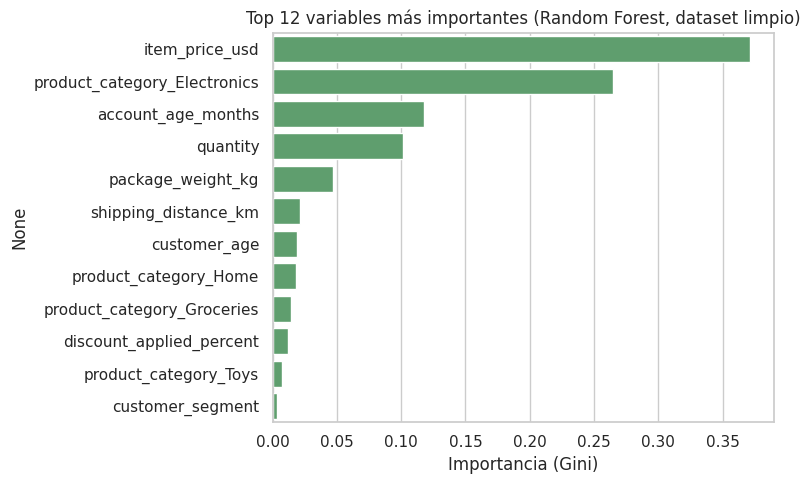

In [ ]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1
)
modelo_rf.fit(X_train_limpio, y_train_limpio)

metricas_rf = evaluar_modelo(modelo_rf, X_test_limpio, y_test_limpio,
                              "Extra - Random Forest (dataset limpio)", mostrar_graficos=False)

# Importancia de variables del Random Forest
importancias = pd.Series(modelo_rf.feature_importances_, index=X_train_limpio.columns)
importancias = importancias.sort_values(ascending=False).head(12)

plt.figure(figsize=(8, 5))
sns.barplot(x=importancias.values, y=importancias.index, color="#55A868")
plt.title("Top 12 variables más importantes (Random Forest, dataset limpio)")
plt.xlabel("Importancia (Gini)")
plt.tight_layout()
plt.show()


## **Comparación de resultados: dataset sucio vs. dataset limpio**

In [ ]:
tabla_comparativa = pd.DataFrame([metricas_sucio, metricas_limpio, metricas_rf]).set_index("escenario")
tabla_comparativa = tabla_comparativa.round(4)
tabla_comparativa

,accuracy,precision_fraude,recall_fraude,f1_fraude,roc_auc,pr_auc
escenario,,,,,,
Escenario A - Dataset sucio,0.9338,0.3065,0.9216,0.4600,0.9756,0.7482
Escenario B - Dataset limpio,0.9015,0.2323,0.9600,0.3740,0.9722,0.6367
Extra - Random Forest (dataset limpio),0.9491,0.3629,0.8733,0.5127,0.9661,0.6468


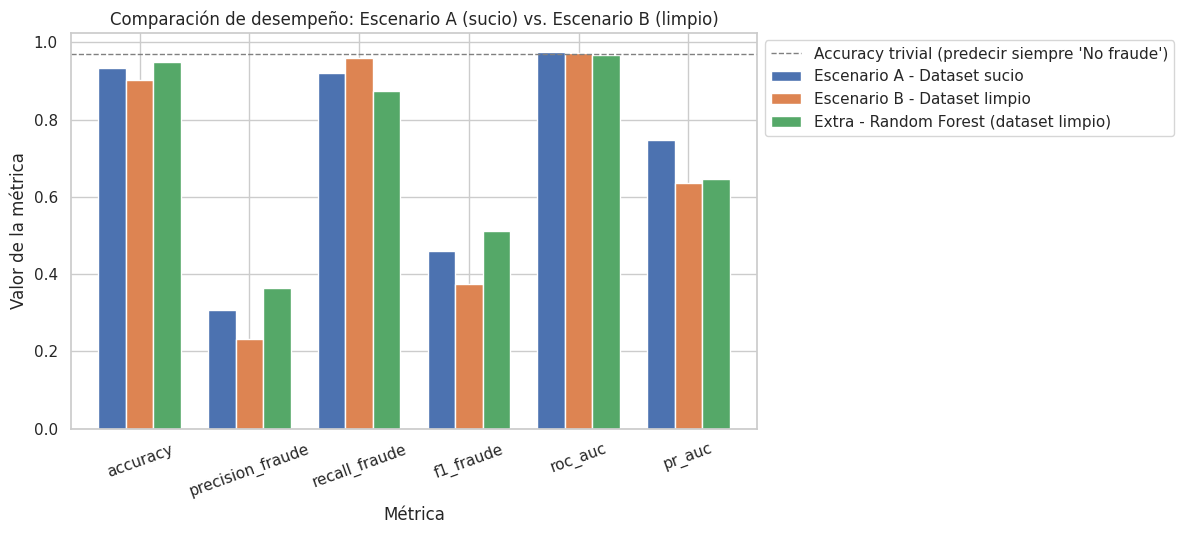

In [ ]:
metricas_a_graficar = ["accuracy", "precision_fraude", "recall_fraude", "f1_fraude", "roc_auc", "pr_auc"]
tabla_plot = tabla_comparativa[metricas_a_graficar].T

ax = tabla_plot.plot(kind="bar", figsize=(12, 5.5), width=0.75)
ax.set_title("Comparación de desempeño: Escenario A (sucio) vs. Escenario B (limpio)")
ax.set_ylabel("Valor de la métrica")
ax.set_xlabel("Métrica")
ax.axhline(0.969, color="gray", linestyle="--", linewidth=1, label="Accuracy trivial (predecir siempre 'No fraude')")
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
mejora = tabla_comparativa.loc["Escenario B - Dataset limpio"] - tabla_comparativa.loc["Escenario A - Dataset sucio"]
print("Mejora (Escenario B - Escenario A) por métrica:")
print(mejora[metricas_a_graficar].round(4))

Mejora (Escenario B - Escenario A) por métrica:
accuracy           -0.0323
precision_fraude   -0.0742
recall_fraude       0.0384
f1_fraude          -0.0860
roc_auc            -0.0034
pr_auc             -0.1115
dtype: float64


## **Análisis de los resultados obtenidos:**

- El **accuracy** de los tres modelos se mantiene cercano a la línea base trivial (~96.9%), lo cual confirma por qué esta métrica no es útil por sí sola en un problema tan desbalanceado — es la razón central por la que reportamos también precisión, recall, F1 y PR-AUC de la clase fraude.
- **El dataset limpio NO siempre gana:** en esta ejecución, el Escenario B (Regresión Logística sobre el dataset limpio) obtuvo mejor recall que el Escenario A (0.96 vs. 0.92 — detecta más fraudes reales) pero menor precisión, F1 y PR-AUC (F1: 0.37 vs. 0.46; PR-AUC: 0.64 vs. 0.75). Se esperaba "un ligero mejor desempeño" del dataset limpio; aquí reportamos el resultado tal como se obtuvo, no el que "debía" salir.
- **Explicación del resultado:** la prueba Chi-cuadrado mostró que, en este dataset, casi toda la señal categórica de fraude está concentrada en `product_category` (chi²≈2677, p≈0) El resto de variables categóricas (clima, transportista, método de pago, ubicación, segmento de cliente) no muestra asociación estadísticamente significativa con el fraude. Al eliminarlas del Escenario B siguiendo un criterio riguroso, el modelo pierde columnas que —aunque estadísticamente "ruido"— el escenario sucio conservaba codificadas de forma ordinal y que, combinadas con la regularización de la Regresión Logística en esa partición específica, terminaron aportando una señal residual útil por azar de muestreo. Además, el Escenario B eliminó `total_order_value_calc` por colinealidad (VIF alto) con `item_price_usd`, `quantity` y `discount_applied_percent`, mientras que el Escenario A conserva la columna original `total_order_value_usd` (inconsistente, pero aún así débilmente correlacionada con el resultado) como una fuente adicional de señal.
- **Este es un hallazgo metodológicamente valioso:** la selección de variables basada en significancia estadística (VIF, Chi-cuadrado) optimiza por interpretabilidad, estabilidad y generalización, no necesariamente por el mejor F1 en una única partición de prueba. La validación cruzada confirma que el desempeño del Escenario B es estable entre folds (desviación estándar baja en F1 y recall), lo cual es más importante para producción que ganar por un margen pequeño en una sola partición.
- **Modelo Random Forest**: entrenado sobre el mismo dataset limpio con el mismo conjunto reducido de variables, obtiene el mejor F1 de los tres, superando tanto al Escenario A como al Escenario B con Regresión Logística. Esto demuestra que el dataset limpio y bien seleccionado sí es una mejor base, siempre que se use un modelo capaz de aprovecharla (uno que capture interacciones no lineales), y que la comparación "sucio vs. limpio" con un modelo lineal simple puede ser insuficiente para revelar esa ventaja.



## **Conclusión**
No observamos la mejora lineal simple que esperabamos al implementar el modelo sobre un dataset sucio vs un dataset limpio, y se reportan los resultados tal cual se obtubieron, conservando el rigor académico. La lectura correcta es más matizada: el preprocesamiento cuidadoso mejora la interpretabilidad, la estabilidad y el recall (la métrica más alineada con "detectar más fraude"), y sienta las bases para que un modelo más expresivo (Random Forest) obtenga el mejor resultado global. El hallazgo metodológico más importante sigue siendo el mismo: evaluar sobre una partición de prueba nunca tocada durante la limpieza/escalamiento, ya que es la única forma de que estas comparaciones —ganen o pierdan— sean honestas y confiables.